#Import Depedencies

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt #data visualization
import seaborn as sns # data visualization
import numpy as np
import math
from google.colab import drive
from matplotlib.offsetbox import AnchoredText
from scipy.signal import periodogram
from tensorflow.keras.models import clone_model

# Beras Premium


#Data Preprocessing

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
harga_2022 = pd.read_excel("/content/drive/MyDrive/Tugas Akhir/export-eceran-2022.xlsx", sheet_name = 1)
harga_2023 = pd.read_excel("/content/drive/MyDrive/Tugas Akhir/export-eceran-2023.xlsx", sheet_name = 1)
harga_2024 = pd.read_excel("/content/drive/MyDrive/Tugas Akhir/export-eceran-2024.xlsx", sheet_name = 1)

In [ ]:
hrg_22 = harga_2022.copy()
hrg_22 = hrg_22.rename(columns={' Komoditas (Rp) ': 'tanggal', 'Beras Premium' : 'beras_premium', 'Beras Medium': 'beras_medium'})
hrg_22 = hrg_22[['tanggal','beras_premium', 'beras_medium']]
hrg_22.head()

,tanggal,beras_premium,beras_medium
0,01/01/2022,12720,11290
1,02/01/2022,12710,11400
2,03/01/2022,12510,11360
3,04/01/2022,12450,11300
4,05/01/2022,12430,11200


In [ ]:
hrg_23 = harga_2023.copy()
hrg_23 = hrg_23.rename(columns={' Komoditas (Rp) ': 'tanggal', 'Beras Premium' : 'beras_premium', 'Beras Medium': 'beras_medium'})
hrg_23 = hrg_23[['tanggal','beras_premium', 'beras_medium']]
hrg_23.head()

,tanggal,beras_premium,beras_medium
0,01/01/2023,12890,11710
1,02/01/2023,12910,11800
2,03/01/2023,12870,11740
3,04/01/2023,12900,11790
4,05/01/2023,12890,11800


In [ ]:
hrg_24 = harga_2024.copy()
hrg_24 = hrg_24.rename(columns={' Komoditas (Rp) ': 'tanggal', 'Beras Premium' : 'beras_premium', 'Beras Medium': 'beras_medium'})
hrg_24 = hrg_24[['tanggal','beras_premium', 'beras_medium']]
hrg_24.head()

,tanggal,beras_premium,beras_medium
0,01/01/2024,14680,13590
1,02/01/2024,14680,13630
2,03/01/2024,14710,13640
3,04/01/2024,14710,13620
4,05/01/2024,14700,13660


In [ ]:
df_beras = pd.concat([hrg_22, hrg_23, hrg_24], ignore_index = True)
df_beras.tail()

,tanggal,beras_premium,beras_medium
877,27/05/2024,15250,13900
878,28/05/2024,15280,13950
879,29/05/2024,15260,14050
880,30/05/2024,15340,13940
881,31/05/2024,15290,13950


In [ ]:
df_beras.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 882 entries, 0 to 881
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   tanggal        882 non-null    object
 1   beras_premium  882 non-null    object
 2   beras_medium   882 non-null    object
dtypes: object(3)
memory usage: 20.8+ KB


In [ ]:
df_premium = df_beras[['tanggal', 'beras_premium']].copy()
df_medium = df_beras[['tanggal', 'beras_medium']].copy()

In [ ]:
df_medium.head()

,tanggal,beras_medium
0,01/01/2022,11290
1,02/01/2022,11400
2,03/01/2022,11360
3,04/01/2022,11300
4,05/01/2022,11200


In [ ]:
df_premium['tanggal'] = pd.to_datetime(df_premium['tanggal'], dayfirst=True)
df_medium['tanggal'] = pd.to_datetime(df_medium['tanggal'], dayfirst=True)
df_premium[['beras_premium']] = df_premium[['beras_premium']].replace('-', np.nan)
df_medium[['beras_medium']] = df_medium[['beras_medium']].replace('-', np.nan)

<ipython-input-11-faab86d6821a>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_premium[['beras_premium']] = df_premium[['beras_premium']].replace('-', np.nan)
<ipython-input-11-faab86d6821a>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_medium[['beras_medium']] = df_medium[['beras_medium']].replace('-', np.nan)


In [ ]:
df_premium.set_index('tanggal', inplace=True)
df_medium.set_index('tanggal', inplace=True)

In [ ]:
df_premium = df_premium.asfreq('D')
df_medium = df_medium.asfreq('D')

In [ ]:
df_premium = df_premium.loc['2022-07-15':].copy()
df_medium = df_medium.loc['2022-07-15':].copy()

Mengisi null value menggunakan teknik interpolasi

https://www.geeksforgeeks.org/how-to-deal-with-missing-values-in-a-timeseries-in-python/

In [ ]:
df_premium['beras_premium'] = df_premium['beras_premium'].interpolate(method='linear')

In [ ]:
df_medium['beras_medium'] = df_medium['beras_medium'].interpolate(method='linear')

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
df_premium = df_premium.astype({'beras_premium': int})
df_medium = df_medium.astype({'beras_medium': int})

In [ ]:
def data_prep(data):
  data['tanggal'] = pd.to_datetime(data['tanggal'], dayfirst=True)
  data[data.columns[1]] = data[data.columns[1]].replace('-', np.nan)
  data.set_index('tanggal', inplace=True)
  data = data.asfreq('D')
  data[data.columns[0]] = data[data.columns[0]].interpolate(method='linear')
  data = data.astype({data.columns[0]: int})
  return data

In [ ]:
df_beras_new = pd.read_excel("/content/drive/MyDrive/Tugas Akhir/export-eceran-baru.xlsx", sheet_name = 1)
df_beras_new = df_beras_new.rename(columns={' Komoditas (Rp) ': 'tanggal', 'Beras Premium' : 'beras_premium', 'Beras Medium': 'beras_medium'})
df_premium_new = data_prep(df_beras_new[['tanggal', 'beras_premium']].copy())
df_medium_new = data_prep(df_beras_new[['tanggal', 'beras_medium']].copy())

<ipython-input-19-ca06cd6b7477>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[data.columns[1]] = data[data.columns[1]].replace('-', np.nan)
<ipython-input-19-ca06cd6b7477>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[data.columns[1]] = data[data.columns[1]].replace('-', np.nan)


In [ ]:
df_premium_new.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 901 entries, 2022-07-15 to 2024-12-31
Freq: D
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   beras_premium  901 non-null    int64
dtypes: int64(1)
memory usage: 14.1 KB


In [ ]:
df_premium.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 687 entries, 2022-07-15 to 2024-05-31
Freq: D
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   beras_premium  687 non-null    int64
dtypes: int64(1)
memory usage: 10.7 KB


In [ ]:
df_medium.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 687 entries, 2022-07-15 to 2024-05-31
Freq: D
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   beras_medium  687 non-null    int64
dtypes: int64(1)
memory usage: 10.7 KB


In [ ]:
# avg_daily = df_beras.loc['2022-09-01':'2024-04-02'].resample('D').beras_premium.mean().to_frame()

# sns.relplot(x = avg_daily.index, y=avg_daily.beras_premium, kind='line', aspect = 3, hue=avg_daily.index.year, palette='viridis')
# plt.xlabel('Date')
# plt.ylabel('Harga')
# plt.title('Grafik Harga Beras Premium')

In [ ]:
# plot_acf(df_premium, lags=30)

In [ ]:
df_medium2 = df_medium.copy()
df_medium2['rollMean'] = df_medium2.beras_medium.rolling(window=365,
                                                          min_periods=183,
                                                          center=True).mean()
df_medium2['rollStd'] = df_medium2.beras_medium.rolling(window=365,
                                                         min_periods=183,
                                                         center=True).std()

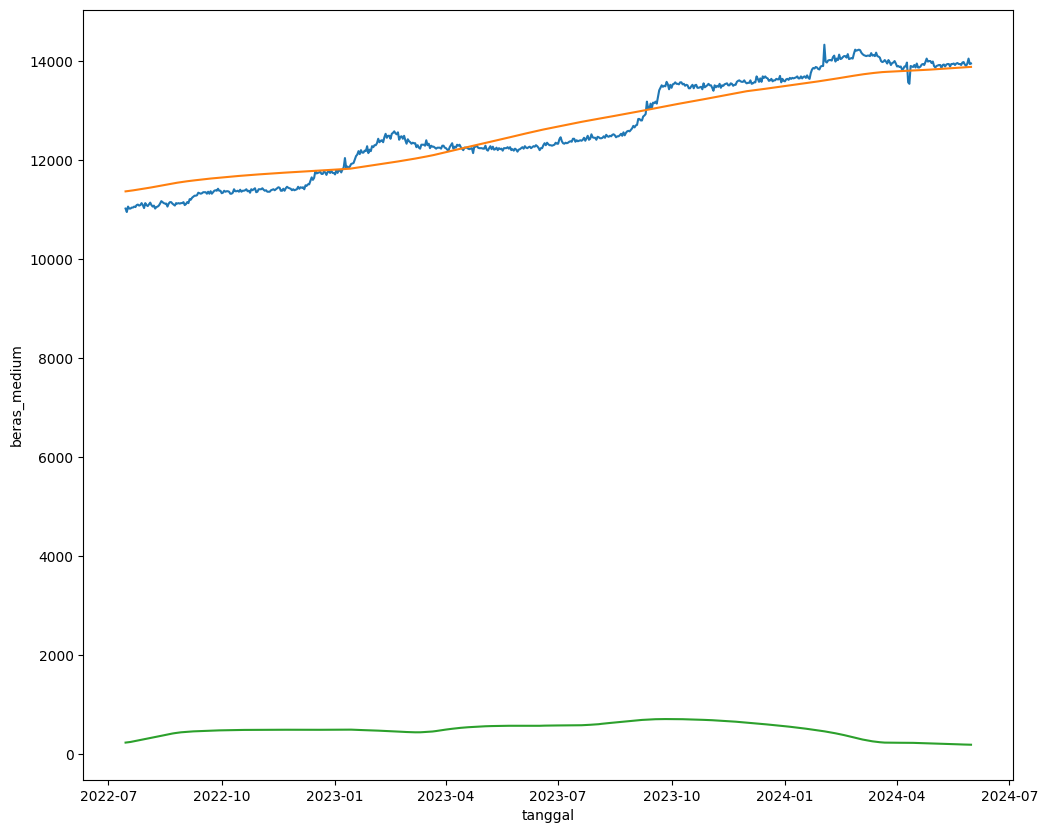

In [ ]:
plt.figure(figsize=(12, 10))
sns.lineplot(data = df_medium2, x = df_medium2.index, y = df_medium2.beras_medium)
sns.lineplot(data = df_medium2, x = df_medium2.index, y = df_medium2.rollMean)
sns.lineplot(data = df_medium2, x = df_medium2.index, y = df_medium2.rollStd)
plt.show()

In [ ]:
import statsmodels.api as sm

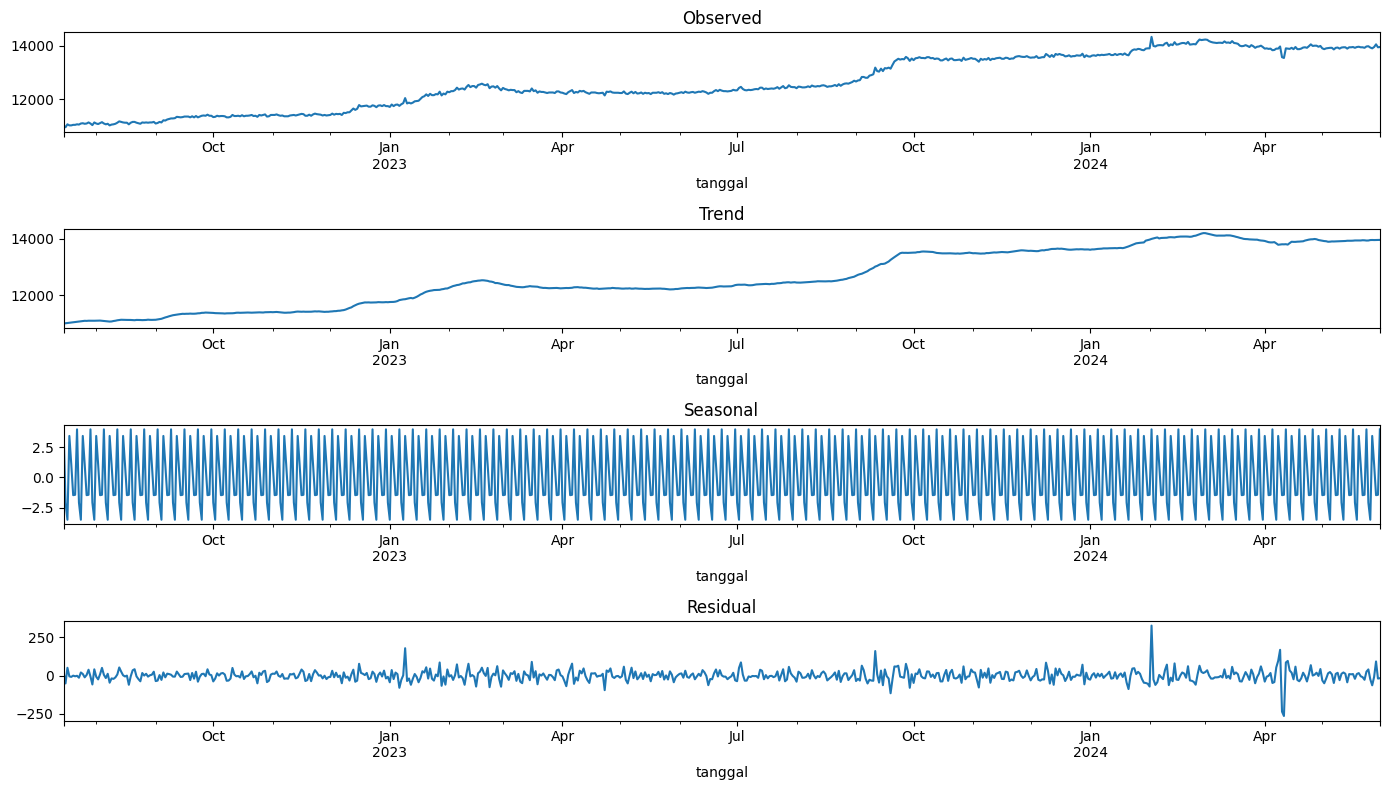

In [ ]:
decomposition = sm.tsa.seasonal_decompose(df_medium, model='additive', extrapolate_trend='freq', period=7)
fig, axes = plt.subplots(4, 1, figsize=(14, 8))

# Plotting the decomposed components
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

In [ ]:
# tren = decomposition.trend
# tren = tren['2024-05']
# # Tampilkan Tren pada Waktu Tertentu
# tren.plot(title='Tren', marker='o')
# plt.show()

In [ ]:
# data_resampled = df_medium.resample('2W').mean()

In [ ]:
# data = df_medium.copy()

In [ ]:
# data['Week_Number'] = data.index.isocalendar().week
# data['Day_of_Week'] = data.index.day_name()

In [ ]:
# plt.figure(figsize=(14, 8))
# sns.lineplot(data=data, x='Day_of_Week', y='beras_medium', hue='Week_Number', palette='tab20', legend=False)
# plt.title('Seasonal Plot: Daily Data Grouped by Weeks')
# plt.show()

In [ ]:
def seasonal_plot(X, y, period, freq):
  fig, ax = plt.subplots(figsize=(15, 8))
  palette = sns.color_palette("husl", n_colors=X[period].nunique())
  sns.lineplot(x=freq, y=y, hue=period, data=X, errorbar=None, ax=ax,
                    palette=palette, legend=False)

  ax.set_title(f"Seasonal Plot ({period}/{freq})")
  for line, name in zip(ax.lines, X[period].unique()):
    y_ = line.get_ydata()[-1]
    ax.annotate(name, xy=(1, y_), xytext=(6, 0), color=line.get_color(), size=14,
                xycoords=ax.get_yaxis_transform(), textcoords="offset points", va="center")

  return ax

def plot_periodogram(ts):
    # Menghitung frekuensi sampling dalam satuan hari
    days_per_year = 365.25
    fs = days_per_year  # 1 year in terms of days

    # Menghitung periodogram
    frequencies, spectrum = periodogram(ts, fs=fs, detrend='linear', window="boxcar", scaling='spectrum')

    # Membuat plot
    _, ax = plt.subplots(figsize=(16, 6))
    ax.step(frequencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(["Annual (1)", "Semiannual (2)", "Quarterly (4)",
                        "Bimonthly (6)", "Monthly (12)", "Biweekly (26)",
                        "Weekly (52)", "Semiweekly (104)"], rotation=30)

    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")

    return ax

In [ ]:
pr_plot = df_medium.copy()

In [ ]:
pr_plot["dow"] = pr_plot.index.dayofweek  # the x-axis (freq)
pr_plot["week"] = pr_plot.index.isocalendar().week.to_numpy()  # the seasonal period (period)

# days within a year
pr_plot["dayofyear"] = pr_plot.index.dayofyear
pr_plot["year"] = pr_plot.index.year

pr_plot['day'] = pr_plot.index.day
pr_plot['month'] = pr_plot.index.month

In [ ]:
pr_plot.head()

,beras_medium,dow,week,dayofyear,year,day,month
tanggal,,,,,,,
2022-07-15,11020,4,28,196,2022,15,7
2022-07-16,10950,5,28,197,2022,16,7
2022-07-17,11060,6,28,198,2022,17,7
2022-07-18,11020,0,29,199,2022,18,7
2022-07-19,11020,1,29,200,2022,19,7


<Axes: title={'center': 'Seasonal Plot (month/day)'}, xlabel='day', ylabel='beras_medium'>

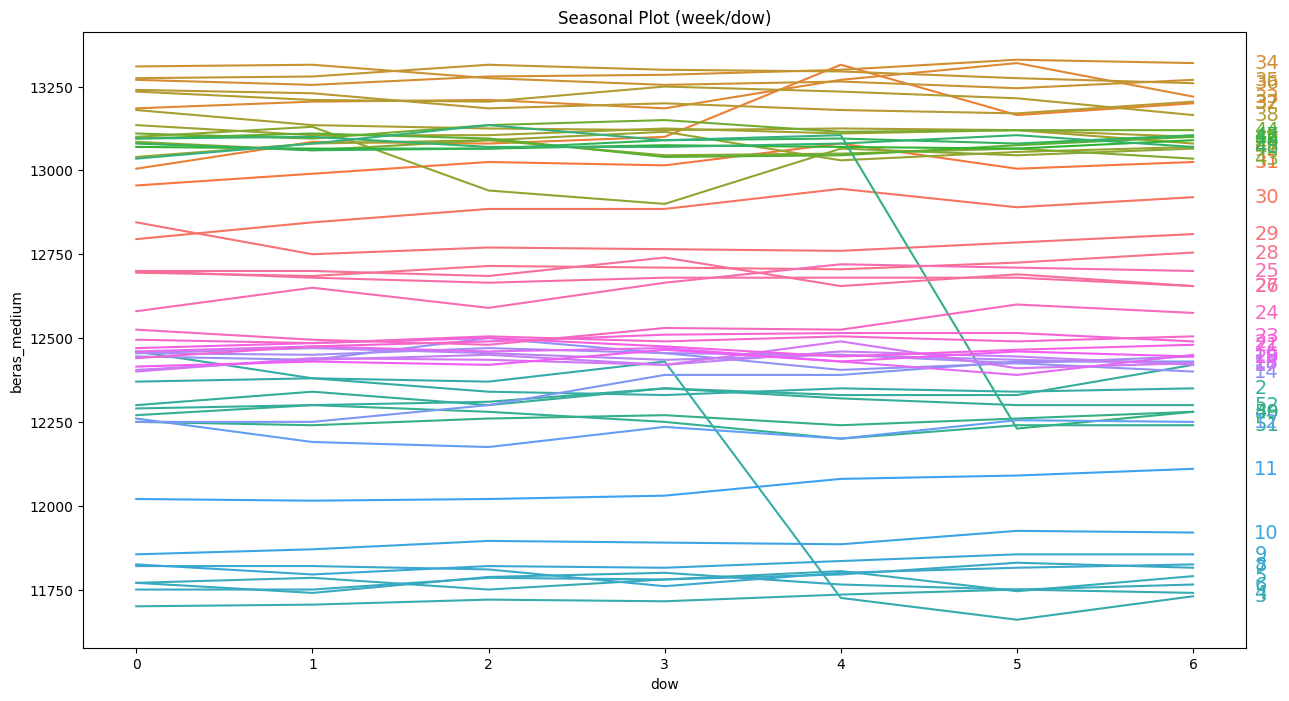

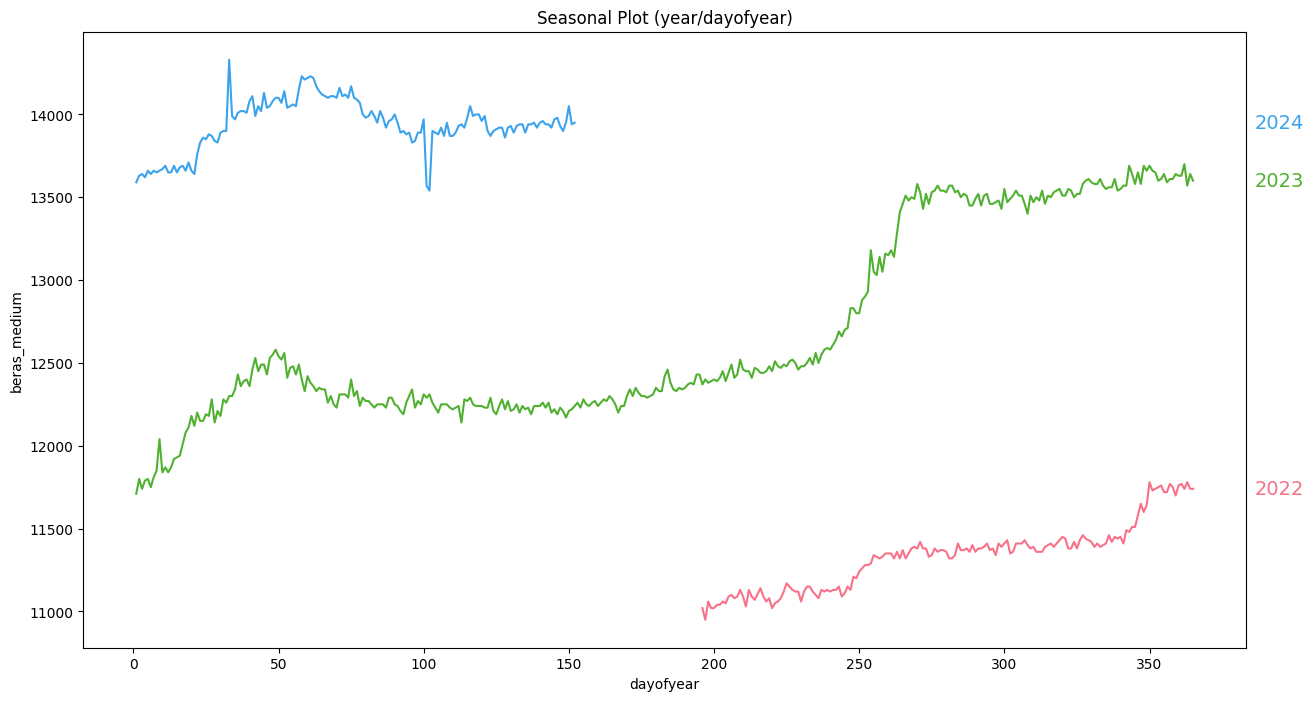

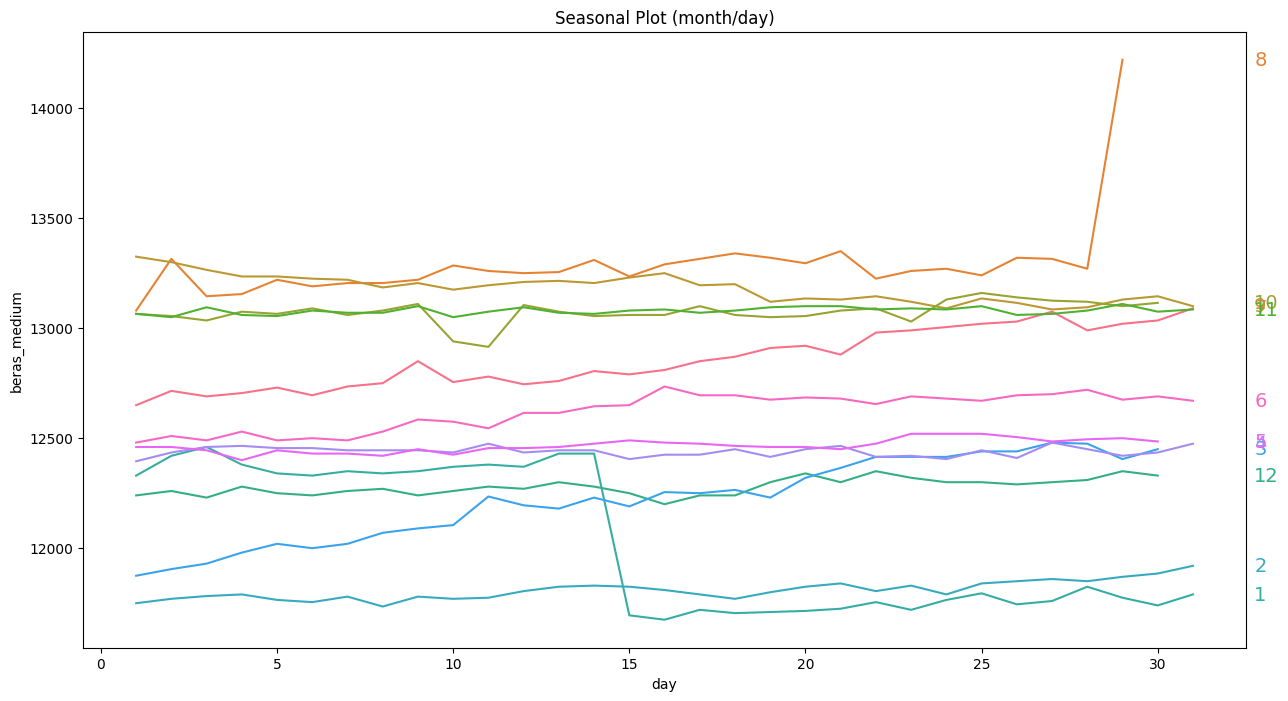

In [ ]:
seasonal_plot(pr_plot, y='beras_medium', period='week', freq='dow')
seasonal_plot(pr_plot, y='beras_medium', period='year', freq='dayofyear')
seasonal_plot(pr_plot, y='beras_medium', period='month', freq='day')

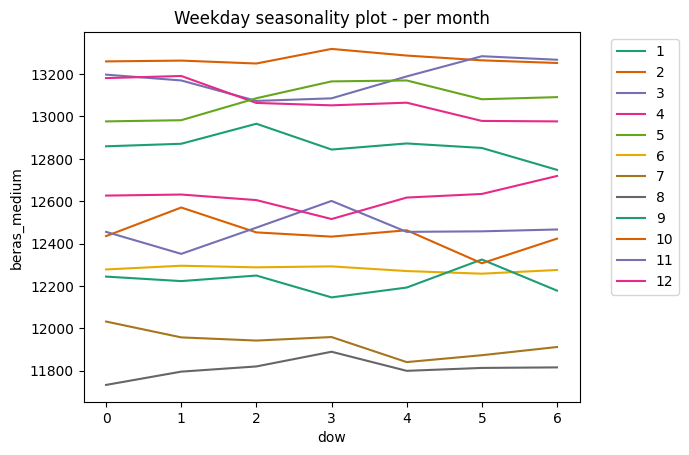

In [ ]:
sns.lineplot(data=pr_plot,
             x='dow',
             y='beras_medium',
             hue='month',
             legend='full',
             palette='Dark2',
             errorbar=None)

# add title
plt.title('Weekday seasonality plot - per month')

# move the legend outside of the main figure
plt.legend(bbox_to_anchor=(1.05, 1), loc=2);

Dikarenakan Data memiliki Seasonality maka model yang akan dibangun adalah SARIMAX

In [ ]:
from statsmodels.tsa.stattools import adfuller
adfTest = adfuller(df_medium['beras_medium'],autolag = 'AIC')
adfTest

(-0.9216781022512107,
 0.7807497115176487,
 14,
 672,
 {'1%': -3.440118534323335,
  '5%': -2.865850549495406,
  '10%': -2.569065506040958},
 7135.700597564872)

In [ ]:
stats = pd.Series(adfTest[0:4], index = ['Test Statistic',
                                         'p-value',
                                         '#lags used',
                                         'number of observations used'])
stats

,0
Test Statistic,-0.921678
p-value,0.780750
#lags used,14.000000
number of observations used,672.000000


In [ ]:
for key, values in adfTest[4].items():
  print('criticality', key, ': ', values)

criticality 1% :  -3.440118534323335
criticality 5% :  -2.865850549495406
criticality 10% :  -2.569065506040958


If  test statistics < criticality then the data is stationary.

Jadi data ini tidak stasioner

menit 28
https://www.youtube.com/watch?v=O5pataOw33Y&t=831s

referensi 2 menit 7:50
https://www.youtube.com/watch?v=2XGSIlgUBDI&t=1077s


# Modelling

## ARIMA

In [ ]:
 from statsmodels.tsa.arima_model import ARIMA
 from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
# def adf_test(series):
#     result = adfuller(series.dropna())
#     print('ADF Statistic: %f' % result[0])
#     print('p-value: %f' % result[1])
#     return result

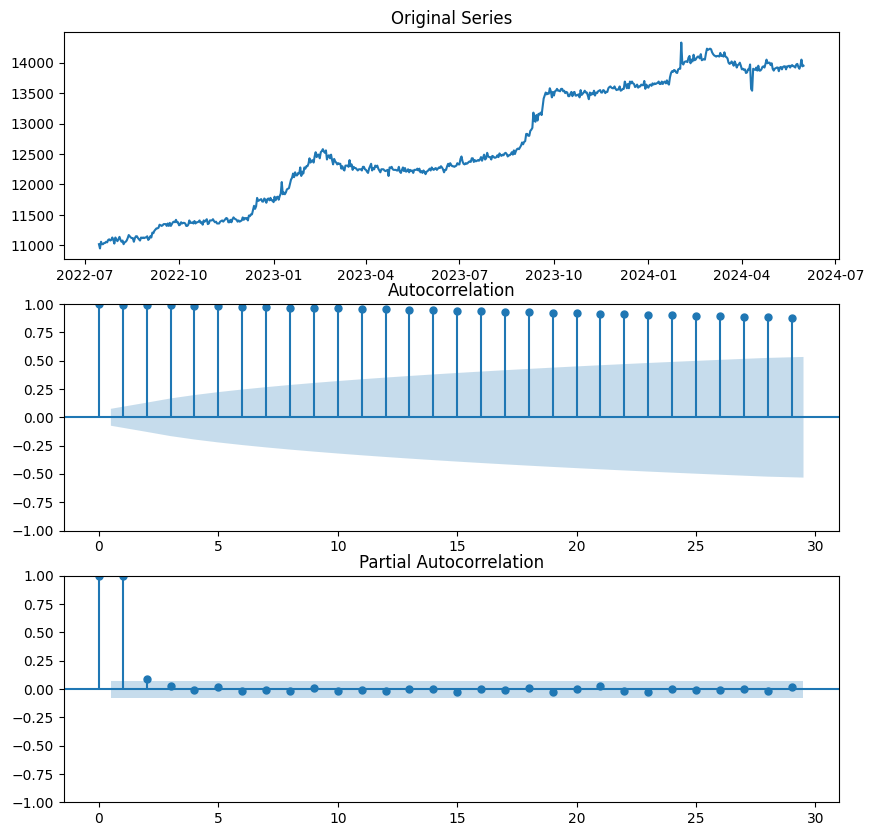

In [ ]:
medium = df_medium.copy()
fig, ax = plt.subplots(3, 1, figsize=(10, 10))
ax[0].plot(medium)
ax[0].set_title('Original Series')
plot_acf(medium, ax=ax[1])
plot_pacf(medium, ax=ax[2])
plt.show()

In [ ]:
medium.head()

,beras_medium
tanggal,
2022-07-15,11020
2022-07-16,10950
2022-07-17,11060
2022-07-18,11020
2022-07-19,11020


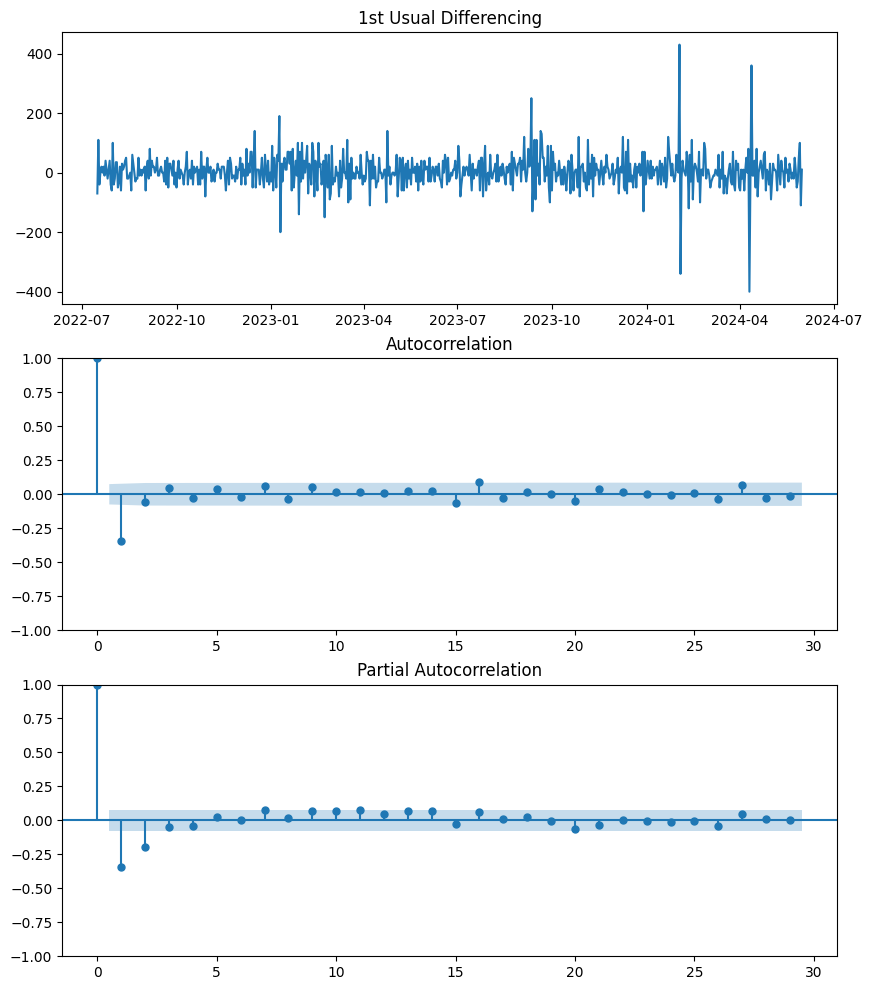

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
axes[0].plot(medium['beras_medium'].diff().dropna()); axes[0].set_title('1st Usual Differencing')
#axes[1].set(ylim=(0,2))
plot_acf(medium['beras_medium'].diff().dropna(), ax=axes[1])
plot_pacf(medium['beras_medium'].diff( ).dropna(), ax=axes[2])

plt.show()

In [ ]:
from scipy import stats
medium['beras_medium'], lmd = stats.boxcox(medium['beras_medium'])
adfTestDiff = adfuller(medium['beras_medium'] ,autolag = 'AIC')
adfTestDiff

(-0.9842821733645831,
 0.7589537633658168,
 14,
 672,
 {'1%': -3.440118534323335,
  '5%': -2.865850549495406,
  '10%': -2.569065506040958},
 -1128.4681573077041)

In [ ]:
medium.head()

,beras_medium
tanggal,
2022-07-15,69.078986
2022-07-16,68.920848
2022-07-17,69.169055
2022-07-18,69.078986
2022-07-19,69.078986


In [ ]:
adfTestDiff = adfuller(medium['beras_medium'].diff().dropna() ,autolag = 'AIC')
adfTestDiff

(-4.881602862067411,
 3.7866925757426955e-05,
 13,
 672,
 {'1%': -3.440118534323335,
  '5%': -2.865850549495406,
  '10%': -2.569065506040958},
 -1127.3425424603806)

In [ ]:
statsDiff = pd.Series(adfTestDiff[0:4], index = ['Test Statistic',
                                         'p-value',
                                         '#lags used',
                                         'number of observations used'])
statsDiff

,0
Test Statistic,-4.881603
p-value,0.000038
#lags used,13.000000
number of observations used,672.000000


In [ ]:
 from statsmodels.tsa.arima.model import ARIMA

In [ ]:
train_md = medium[:-14]
train_md2 = medium[:math.floor(len(medium)*0.85)]
train_md.head()

,beras_medium
tanggal,
2022-07-15,69.078986
2022-07-16,68.920848
2022-07-17,69.169055
2022-07-18,69.078986
2022-07-19,69.078986


In [ ]:
test_md = medium[-14:]
test_md2 = medium[math.floor(len(medium)*0.85):]
test_md.head()

,beras_medium
tanggal,
2024-05-18,75.123222
2024-05-19,75.181219
2024-05-20,75.200533
2024-05-21,75.161896
2024-05-22,75.161896


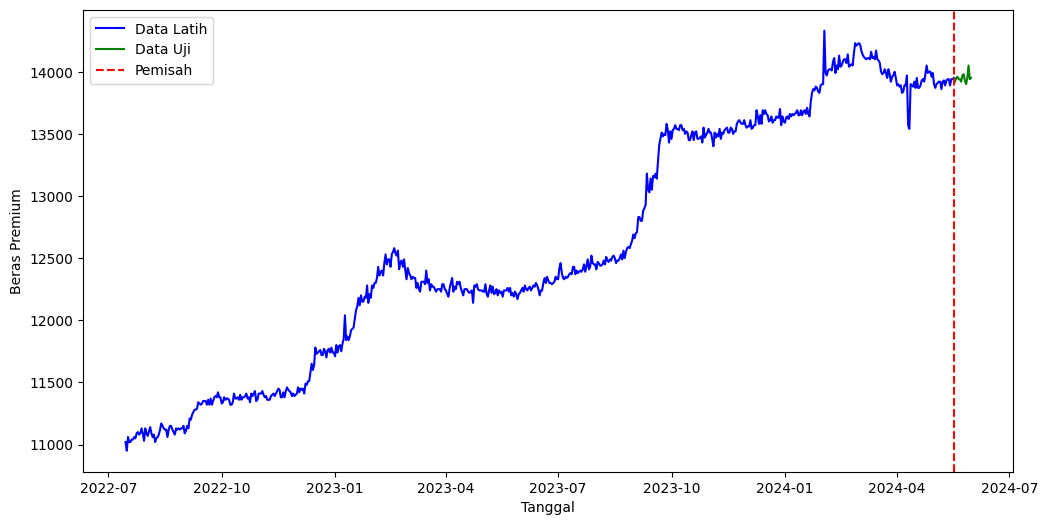

In [ ]:
#pembagian sarima beras medium
train_md2 = df_medium[:-14]
test_md2 = df_medium[-14:]
plt.figure(figsize=(12, 6))
sns.lineplot(data = train_md2, x = train_md2.index, y = train_md2.beras_medium, color='blue', label='Data Latih')
sns.lineplot(data = test_md2, x = test_md2.index, y = test_md2.beras_medium, color='green', label='Data Uji')
plt.axvline(train_md2[-1:].index, color="red", linestyle="--", label="Pemisah")
plt.legend()
plt.xlabel("Tanggal")
plt.ylabel("Beras Premium")
# plt.grid(alpha=0.5)
plt.show()

In [ ]:
model_md = ARIMA(train_md['beras_medium'], order=(2,1,1))
model_md_fit = model_md.fit()

In [ ]:
result_am = medium.copy()
am_pred = model_md_fit.predict(start = test_md.index[0], end = test_md.index[-1])
am_pred2 = model_md_fit.predict(start = train_md.index[0], end = train_md.index[-1])
result_am['test_pred'] = am_pred
result_am['train_pred'] = am_pred2

In [ ]:
am_pred2.head()

,predicted_mean
tanggal,
2022-07-15,0.000000
2022-07-16,69.078985
2022-07-17,68.973785
2022-07-18,69.098559
2022-07-19,69.073968


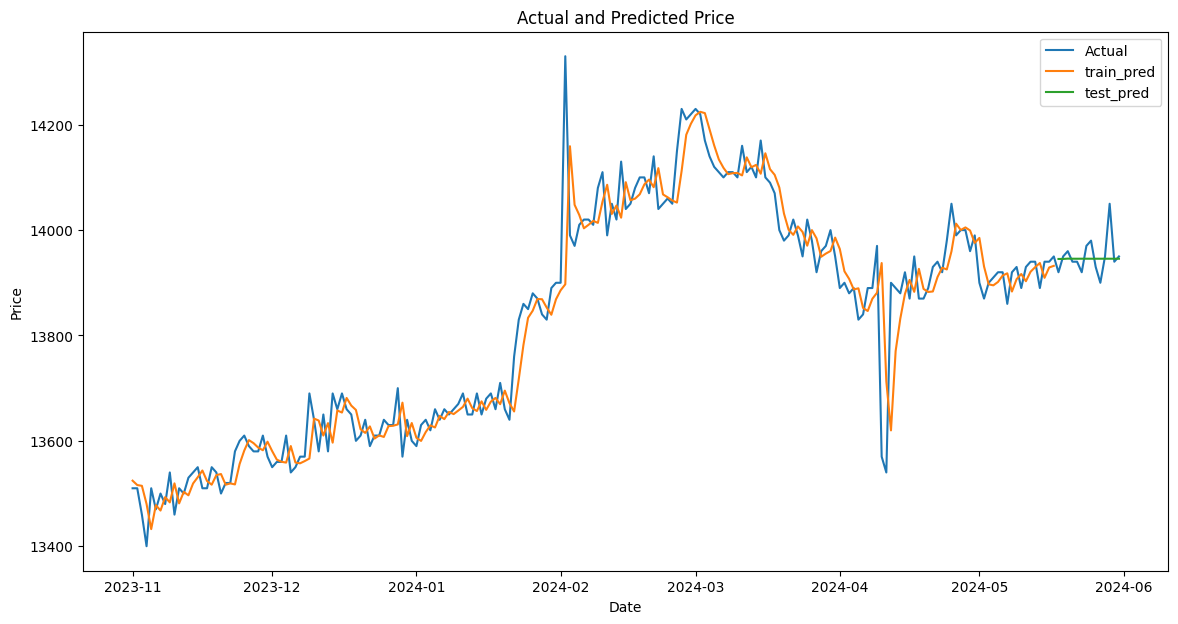

In [ ]:
from scipy.special import inv_boxcox

plt.figure(figsize=(14, 7))
subset_data = inv_boxcox(result_am.loc['2023-11':], lmd)
sns.lineplot(data=subset_data, x=subset_data.index, y='beras_medium', label='Actual')
sns.lineplot(data=subset_data, x=subset_data.index, y='train_pred', label='train_pred')
sns.lineplot(data=subset_data, x=subset_data.index, y='test_pred', label='test_pred')

plt.title('Actual and Predicted Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
result_am.head()

,beras_medium,test_pred,train_pred
tanggal,,,
2022-07-15,69.078986,NaN,0.000000
2022-07-16,68.920848,NaN,69.078985
2022-07-17,69.169055,NaN,68.973785
2022-07-18,69.078986,NaN,69.098559
2022-07-19,69.078986,NaN,69.073968


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

def arima_error(actual, pred):
  mae = mean_absolute_error(actual, pred)
  mape = mean_absolute_percentage_error(actual, pred) * 100

  return({'MAE' : mae,
          'MAPE' : mape})


In [ ]:
print(f"Train Error : {arima_error(inv_boxcox(train_md['beras_medium'], lmd)[1:], inv_boxcox(am_pred2, lmd)[1:])}")
print(f"Test Error : {arima_error(inv_boxcox(test_md['beras_medium'], lmd), inv_boxcox(am_pred, lmd))}")

Train Error : {'MAE': 34.88028402531212, 'MAPE': 0.27502720066150727}
Test Error : {'MAE': 22.839670566436716, 'MAPE': 0.16344228084992538}


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
adfTestDiff2 = adfuller(medium['beras_medium'].diff(7).dropna() ,autolag = 'AIC')
statsDiff2 = pd.Series(adfTestDiff2[0:4], index = ['Test Statistic',
                                         'p-value',
                                         '#lags used',
                                         'number of observations used'])
statsDiff2

,0
Test Statistic,-4.897581
p-value,0.000035
#lags used,20.000000
number of observations used,659.000000


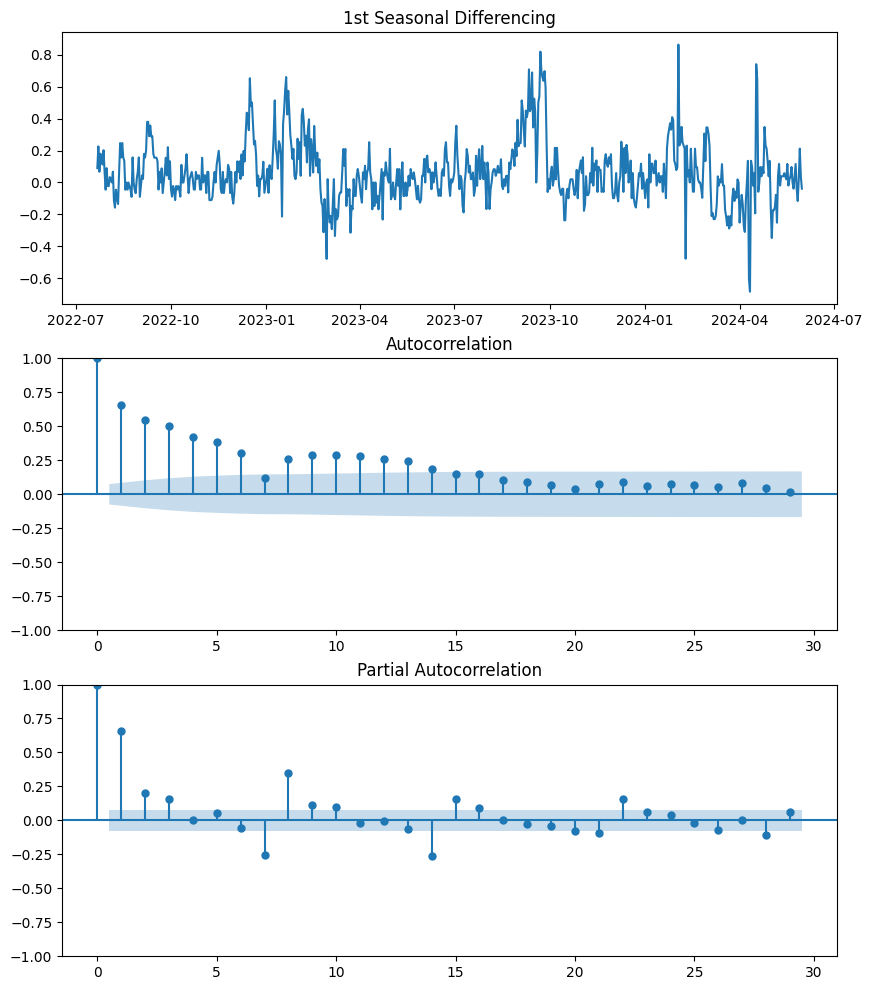

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
axes[0].plot(medium['beras_medium'].diff(7).dropna()); axes[0].set_title('1st Seasonal Differencing')
plot_acf(medium['beras_medium'].diff(7).dropna(), ax=axes[1])
plot_pacf(medium['beras_medium'].diff(7).dropna(), ax=axes[2])

plt.show()

In [ ]:
# medium['seasonalDiff'] = medium['beras_medium'].diff().diff(7)

In [ ]:
model_pm2 = SARIMAX(train_md['beras_medium'], order = (2,1,1), seasonal_order = (3,1,1,7))
model_pm2_fit = model_pm2.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
sm_pred = model_pm2_fit.predict(start = test_md.index[0], end = test_md.index[-1])
# sm_pred = model_pm2_fit.forecast(step=200)
sm_pred2 = model_pm2_fit.predict(start = train_md.index[0], end = train_md.index[-1])
result_sm = medium.copy()
result_sm['test_pred'] = sm_pred
result_sm['train_pred'] = sm_pred2

In [ ]:
result_sm.head()

,beras_medium,test_pred,train_pred
tanggal,,,
2022-07-15,69.078986,NaN,0.000000
2022-07-16,68.920848,NaN,69.078985
2022-07-17,69.169055,NaN,68.920848
2022-07-18,69.078986,NaN,69.169055
2022-07-19,69.078986,NaN,69.078986


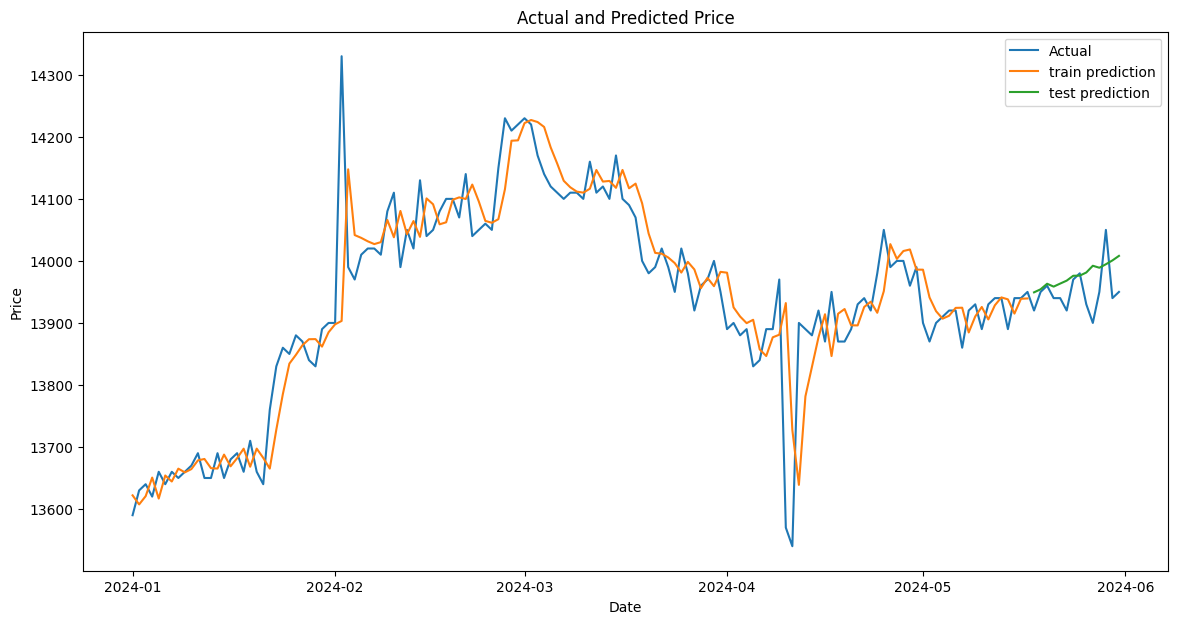

In [ ]:
plt.figure(figsize=(14, 7))

subset_data = inv_boxcox(result_sm.loc['2024-01':], lmd)
sns.lineplot(data=subset_data, x=subset_data.index, y='beras_medium', label='Actual')
sns.lineplot(data=subset_data, x=subset_data.index, y='train_pred', label='train prediction')
sns.lineplot(data=subset_data, x=subset_data.index, y='test_pred', label='test prediction')

plt.title('Actual and Predicted Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
print(f"Train Error : {arima_error(inv_boxcox(train_md['beras_medium'], lmd)[8:], inv_boxcox(sm_pred2, lmd)[8:])}")
print(f"Test Error : {arima_error(inv_boxcox(test_md['beras_medium'], lmd), inv_boxcox(sm_pred, lmd))}")

Train Error : {'MAE': 35.66429317247413, 'MAPE': 0.2810009893957574}
Test Error : {'MAE': 35.239708857825725, 'MAPE': 0.2527336359504603}


###Finding Best Parameters for SARIMA


In [ ]:
medium.head()

,beras_medium
tanggal,
2022-07-15,69.078986
2022-07-16,68.920848
2022-07-17,69.169055
2022-07-18,69.078986
2022-07-19,69.078986


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.8 MB/s eta 0:00:00


In [ ]:
import pmdarima as pm

def auto_arima(x_train):
  model_auto = pm.auto_arima(x_train,
                             seasonal=True,
                             m=7,
                             d=None,
                             D=None,
                             with_intercept=False,
                             start_q=0,
                             max_p=2, max_q=1,
                             max_P=3, max_Q=6,
                             trace=True,
                             error_action='ignore',
                             suppress_warnings=True,
                             stepwise=False)

  print(model_auto.summary())
  return model_auto

In [ ]:
model_auto = auto_arima(train_md)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

 ARIMA(0,1,0)(0,0,0)[7]             : AIC=-1032.615, Time=0.19 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,1)[7]             : AIC=-1033.814, Time=0.52 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(2,1,1)(1,0,0)[7]             : AIC=-1130.661, Time=0.76 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(1,0,1)[7]             : AIC=-1131.087, Time=1.79 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(2,0,0)[7]             : AIC=-1130.408, Time=0.93 sec

Best model:  ARIMA(0,1,1)(1,0,1)[7]          
Total fit time: 152.460 seconds
                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  673
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 7)   Log Likelihood                 570.478
Date:                           Fri, 07 Feb 2025   AIC                          -1132.957
Time:                                   07:42:30   BIC                          -1114.916
Sample:                               07-15-2022   HQIC                         -1125.970
                                    - 05-17-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [ ]:
# train_auto = model_auto.predict_in_sample()
# test_auto = model_auto.predict(n_periods = len(test_md))
# print(f"Train Error : {arima_error(train_md['beras_medium'], train_auto)}")
# print(f"Test Error : {arima_error(test_md['beras_medium'], test_auto)}")

In [ ]:
# result_auto = df_medium.copy()
# result_auto['train_pred'] = train_auto
# result_auto['test_pred'] = test_auto

# plt.figure(figsize=(14, 7))

# subset_data = result_auto.loc['2023-11':]
# sns.lineplot(data=subset_data, x=subset_data.index, y='beras_medium',label='Actual')
# sns.lineplot(data=subset_data, x=subset_data.index, y='train_pred',label='Train Prediction')
# sns.lineplot(data=subset_data, x=subset_data.index, y='test_pred',label='Test Prediction')

# plt.title('Actual and Predicted Price')
# plt.xlabel('Date')
# plt.ylabel('Price')
# plt.legend()
# plt.show()

In [ ]:
model_sm2 = SARIMAX(train_md, order = (0,1,1), seasonal_order = (1,0,1,7))
model_sm2_fit = model_sm2.fit()

In [ ]:
sm2_pred = model_sm2_fit.predict(start = test_md.index[0], end = test_md.index[-1])
sm2_pred2 = model_sm2_fit.predict(start = train_md.index[0], end = train_md.index[-1])
result_sm2 = medium.copy()
result_sm2['train_pred'] = sm2_pred2
result_sm2['test_pred'] = sm2_pred

In [ ]:
# result_sm2.tail()

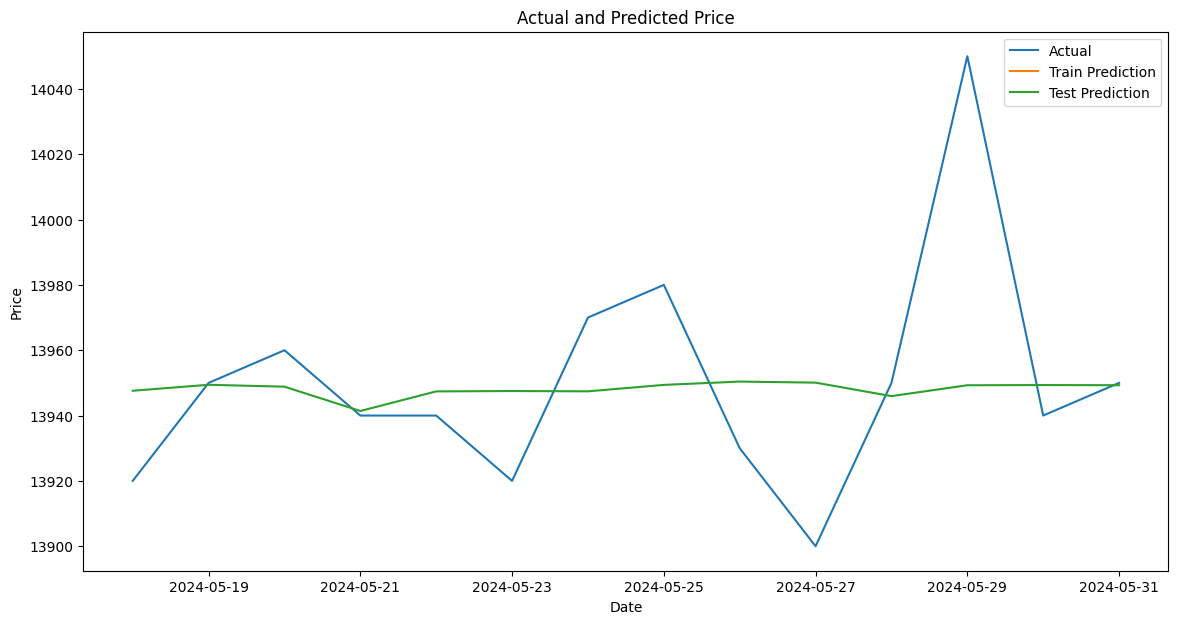

In [ ]:
plt.figure(figsize=(14, 7))

subset_data = inv_boxcox(result_sm2.loc['2024-05-18':], lmd)
sns.lineplot(data=subset_data, x=subset_data.index, y='beras_medium',label='Actual')
sns.lineplot(data=subset_data, x=subset_data.index, y='train_pred',label='Train Prediction')
sns.lineplot(data=subset_data, x=subset_data.index, y='test_pred',label='Test Prediction')

plt.title('Actual and Predicted Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
print(f"Train Error : {arima_error(inv_boxcox(train_md['beras_medium'], lmd)[1:], inv_boxcox(sm2_pred2, lmd)[1:])}")
print(f"Test Error : {arima_error(inv_boxcox(test_md['beras_medium'], lmd), inv_boxcox(sm2_pred, lmd))}")

Train Error : {'MAE': 34.6155562766043, 'MAPE': 0.27280406319318135}
Test Error : {'MAE': 22.438556653216178, 'MAPE': 0.16060320199739356}


In [ ]:
import os

os.makedirs('model_final_forecasting', exist_ok=True)
os.makedirs('model_final_forecasting/arima', exist_ok=True)
os.makedirs('model_final_forecasting/hybrid', exist_ok=True)

In [ ]:
#Export Model
import joblib

joblib.dump(model_sm2_fit, 'model_final_forecasting/arima/sarima_model_tr.pkl')

['model_final_forecasting/arima/sarima_model_tr.pkl']

##LSTM

In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0,1))
df_scaled = sc.fit_transform(df_medium)

In [ ]:
joblib.dump(sc, 'scaler_lstm.pkl')

['scaler_lstm.pkl']

<Axes: title={'center': 'Distribution after MinMax Scaling'}, xlabel='beras_medium', ylabel='Density'>

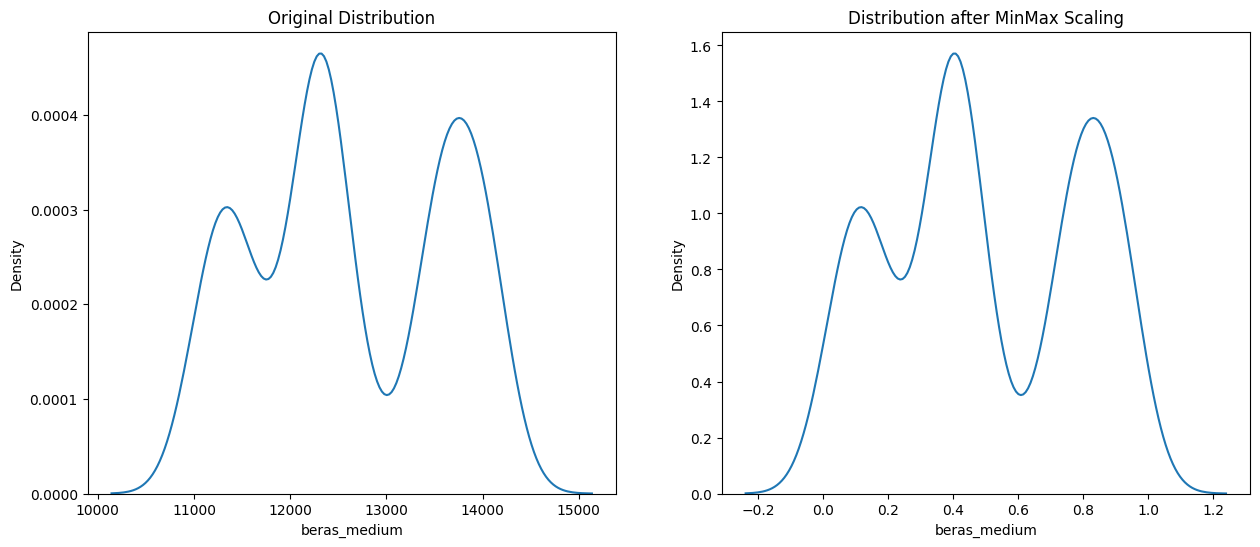

In [ ]:
fig, (ax0,ax1) = plt.subplots(ncols=2, figsize = (15,6))
ax0.set_title('Original Distribution')
ax1.set_title('Distribution after MinMax Scaling')
sns.kdeplot(df_medium['beras_medium'], ax = ax0)
sns.kdeplot(pd.DataFrame(df_scaled, columns=['beras_medium'])['beras_medium'], ax=ax1)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import Dense
from keras.layers import Input
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [ ]:
def make_data_lstm(df, window_size):
  x = []
  y = []
  for i in range(window_size, len(df)):
    x.append(df[i-window_size:i,0])
    y.append(df[i,0])
  return np.array(x), np.array(y)

In [ ]:
window = 5
x, y = make_data_lstm(df_scaled, window)
print(x.shape)
print(y.shape)

(682, 5)
(682,)


In [ ]:
# x_train = x[:math.floor(len(df_medium)*0.8)]
# y_train = y[:math.floor(len(df_medium)*0.8)]
# x_test = x[math.floor(len(df_medium)*0.8):]
# y_test = y[math.floor(len(df_medium)*0.8):]

x_train = x[:-14]
y_train = y[:-14]
x_test = x[-14:]
y_test = y[-14:]

In [ ]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1],1))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1],1))

In [ ]:
x_train.shape

(668, 5, 1)

### Hyperparameter Tuning

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 7.8 MB/s eta 0:00:00


In [ ]:
from keras_tuner.tuners import GridSearch, RandomSearch

In [ ]:
def build_model(hp):
  model = Sequential()
  model.add(Input(shape=(x_train.shape[1], 1)))
  hp_units1 = hp.Choice('units1', values = [16, 32, 64])
  model.add(LSTM(units = hp_units1, return_sequences=True))
  hp_dropout1 = hp.Float('dropout1', min_value=0.1, max_value=0.4, step=0.1)
  model.add(Dropout(hp_dropout1))

  hp_units2 = hp.Choice('units2', values = [16, 32, 64])
  model.add(LSTM(units = hp_units2))
  hp_dropout2 = hp.Float('dropout2', min_value=0.1, max_value=0.4, step=0.1)
  model.add(Dropout(hp_dropout2))

  model.add(Dense(units = 1))

  hp_learning_rate = hp.Choice('learning_rate', values=[0.005, 0.0005])
  model.compile(optimizer = keras.optimizers.Adam(learning_rate = hp_learning_rate),
                loss = 'mse', metrics = ['mae', 'mape'])

  return model

In [ ]:
# import os
# source_dir = 'my_dir'

# target_dir = '/content/drive/My Drive/hasil_tuner_lstm/lstm-md'

# shutil.copytree(source_dir, target_dir)

In [ ]:
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials = 30,
    executions_per_trial=2,
    directory='/content/drive/My Drive/Tugas Akhir/hasil_tuner_lstm/lstm-md',
    project_name='lstm_tuning'
)

Reloading Tuner from /content/drive/My Drive/Tugas Akhir/hasil_tuner_lstm/lstm-md/lstm_tuning/tuner0.json


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                                  mode = 'min', patience = 20,
                                                  restore_best_weights=True)

tuner.search(x_train, y_train,
             epochs=100,
             validation_split = 0.2,
             batch_size = 32,
             callbacks=[early_stopping])

In [ ]:
# best_models = tuner.get_best_models(num_models=1)[0]

In [ ]:
best_param = tuner.get_best_hyperparameters(num_trials=1)[0]
for param in best_param.values:
    print(f"{param}: {best_param.get(param)}")

units1: 64
dropout1: 0.2
units2: 32
dropout2: 0.30000000000000004
learning_rate: 0.005


In [ ]:
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'loss', mode = 'min', patience = 20)


# hist = model.fit(x_train, y_train, epochs = 100, batch_size = 32,
#                     callbacks = [early_stopping, mc], verbose = 0)
#   )

In [ ]:
# #Build model
# def make_model(x_train, y_train, num_epoch):
#   if num_epoch < 1000:
#     num_patience = 20
#   else:
#     num_patience = 300

#   keras.backend.clear_session()
#   tf.random.set_seed(42)
#   # np.random.seed(1)

#   model = Sequential()
#   model.add(Input(shape=(x_train.shape[1], 1)))

#   model.add(LSTM(units = 128, return_sequences=True))
#   model.add(Dropout(0.2))

#   model.add(LSTM(units = 32))
#   model.add(Dropout(0.2))

#   model.add(Dense(units = 1))

#   opt = keras.optimizers.Adam(learning_rate = 0.005)
#   model.compile(optimizer = opt, loss = 'mse', metrics = ['mae', 'mape'])

#   early_stopping = EarlyStopping(monitor = 'loss', mode = 'min',
#                                  patience = num_patience, restore_best_weights=True)
#   # reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.1,
#   #                               patience=num_patience/5, min_lr=0.0005)

#   hist = model.fit(x_train, y_train, epochs = num_epoch, batch_size = 32,
#                    callbacks = [early_stopping],
#                   #  validation_data=(x_test, y_test),
#                    verbose = 0)

#   return model, hist

In [ ]:
best_models = tuner.get_best_models(num_models=1)[0]

In [ ]:
tf.random.set_seed(42)

In [ ]:
keras.backend.clear_session()
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                                  mode = 'min', patience = 20,
                                                  restore_best_weights=True)

lr = best_param.get('learning_rate')
model_clone = clone_model(best_models)
model_clone.compile(optimizer = keras.optimizers.Adam(learning_rate = lr),
                           loss = 'mse', metrics = ['mae', 'mape'])

hist = model_clone.fit(x_train, y_train,
                       epochs=100,
                       validation_split = 0.2,
                       batch_size=32,
                       callbacks=[early_stopping],
                       verbose=0)

In [ ]:
model_clone.summary()

In [ ]:
plt.plot(hist.history['loss'])
plt.show()

In [ ]:
model_clone.save('lstm_model_tr_recursive.keras')

In [ ]:
train_pred = model_clone.predict(x_train)
train_pred = sc.inverse_transform(train_pred)
y_train_actual = sc.inverse_transform(y_train.reshape(-1,1))

In [ ]:
def lstm_error(actual, pred):
  mape = keras.metrics.MeanAbsolutePercentageError()
  mae = keras.metrics.MeanAbsoluteError()

  mape.update_state(actual, pred)
  mae.update_state(actual, pred)

  return({'MAE' : mae.result().numpy(),
          'MAPE' : mape.result().numpy()})

In [ ]:
train_errors = lstm_error(y_train_actual, train_pred)
print(f'Train Errors : {train_errors}')

In [ ]:
def plot_result_lstm (split_name, actual, pred):
  plt.figure(figsize=(14, 7))
  x_range = range(1, len(actual)+1)
  plt.plot(x_range, actual, color ='red', label = 'Aktual')
  plt.plot(x_range, pred, color = 'blue', label = 'Prediksi')
  plt.title(f'Aktual vs Prediksi ({split_name})')
  plt.xlabel('Hari')
  plt.ylabel('Harga')
  plt.legend(['Aktual', 'Prediksi'], loc = 'upper left')
  plt.show()

In [ ]:
plot_result_lstm('Train', y_train_actual, train_pred)

In [ ]:
test_pred = model_clone.predict(x_test)
test_pred = sc.inverse_transform(test_pred)
y_test_actual = sc.inverse_transform(y_test.reshape(-1,1))

In [ ]:
test_errors = lstm_error(y_test_actual, test_pred)
print(f'Test Errors : {test_errors}')

In [ ]:
plot_result_lstm('Test', y_test_actual, test_pred)

In [ ]:
# demonstrate prediction for next 10 days
def lstm_forecast(steps):
  x_input = df_scaled[:-(steps)][-(window):]
  temp_input =  x_input
  output=[]
  i=0
  while(i<steps):
    x_input = temp_input
    x_input = x_input.reshape((1, window, 1))
    # print("{} day input {}".format(i,x_input))
    pred = model_clone.predict(x_input, verbose=0)
    # print("{} day output {}".format(i,pred))
    temp_input = temp_input[1:]
    temp_input = np.append(temp_input, pred[0][0])
    output = np.append(output, pred[0][0])
    i=i+1
  pred = sc.inverse_transform(output.reshape(-1,1))
  return pred, steps

In [ ]:
pred, steps = lstm_forecast(steps = 14)

In [ ]:
lstm_recursive = df_medium[-(steps):].copy()
lstm_recursive['Prediction'] = pred

In [ ]:
lstm_recursive.head()

In [ ]:
recursive_errors = lstm_error(lstm_recursive['beras_medium'], lstm_recursive['Prediction'])
print(f'Test Errors : {recursive_errors}')

In [ ]:
plot_result_lstm('Forecast', lstm_recursive['beras_medium'], lstm_recursive['Prediction'])

### Direct Strategy


In [ ]:
def make_data_direct(data, window_size, n_steps):
  x1, y1 = [], []
  for i in range(len(data) - window_size - n_steps + 1):
    x1.append(data[i:(i + window_size)])
    y1.append(data[(i + window_size):(i + window_size + n_steps)])

  return np.array(x1), np.array(y1)

In [ ]:
window_size = 5
n_steps = 14
x1,y1 = make_data_direct(df_scaled, window_size, n_steps)

In [ ]:
print(x1.shape)
print(y1.shape)

(669, 5, 1)
(669, 14, 1)


In [ ]:
x_train1 = x1[:-n_steps]
y_train1 = y1[:-n_steps]
x_test1 = x1[-n_steps:]
y_test1 = y1[-n_steps:]

In [ ]:
def fitting(model, x, y, epoch, val_split, isHybrid = False):
  keras.backend.clear_session()
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                                  mode = 'min', patience = 20,
                                                  restore_best_weights=True)

  callback = [early_stopping]
  if isHybrid == True:
    callback = None

  hist = model.fit(x, y,
                   epochs = epoch,
                   validation_split = val_split,
                   batch_size=32,
                   callbacks=callback,
                   verbose=0)

  return model, hist

In [ ]:
# build all models
lr = best_param.get('learning_rate')
models = []
rows =  math.ceil(n_steps/2)
cols = 2
step_temp = 0
fig,axs = plt.subplots(rows, cols, figsize=(15, 30))
for i in range(rows):
  for j in range(cols):
    model_clone1 = clone_model(best_models)
    model_clone1.compile(optimizer = keras.optimizers.Adam(learning_rate = lr),
                           loss = 'mse', metrics = ['mae', 'mape'])
    regressor1, hist = fitting(model_clone1, x_train1, y_train1[:, (step_temp)], 100, isHybrid = False)
    models.append(regressor1)
    if step_temp < n_steps:
      ax = axs[i,j]
      ax.plot(hist.history['loss'], label=f'Model Loss ({step_temp+1})')
      ax.legend()
      step_temp += 1
    else:
      fig.delaxes(axs[i,j])
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import load_model
models = []
# Memuat model dari file .h5
for i in range(14):
  model_tr = load_model(f'/content/drive/MyDrive/Tugas Akhir/model_akhir/medium/lstm/lstm_model_tr_{i}.keras')
  models.append(model_tr)
# Menampilkan ringkasan arsitektur model
# model.summary()

In [ ]:
# def direct_prediction(model, x):
#   return model.predict(x).flatten()

In [ ]:
def direct_lstm_pred(models, x, scaler, n_steps):
  # predict
  direct_pred = np.zeros((x.shape[0], n_steps))
  for i, regs in enumerate(models):
    direct_pred[:, i] = regs.predict(x).flatten()
  direct_pred = scaler.inverse_transform(direct_pred)

  return direct_pred

In [ ]:
#calculating error
def lstm_error_direct(actual, pred, scaler, n_steps, hybrid: bool):
  if not isinstance(hybrid, bool):
    raise ValueError("Expected Boolean (True or False)")

  if (hybrid==False):
    y_actual = scaler.inverse_transform(actual.reshape(actual.shape[0], actual.shape[1]))
  elif (hybrid==True):
    y_actual = actual.reshape(actual.shape[0], actual.shape[1])
    pred = pred.to_numpy()

  erors_data = []
  for i in range(n_steps):
    erors_temp = lstm_error(y_actual[:, i], pred[:, i])
    erors_dict = {'Step' : i+1}
    erors_dict.update(erors_temp)
    erors_data.append(erors_dict)
  df_direct_err = pd.DataFrame(erors_data)

  return df_direct_err

In [ ]:
def lstm_direct_plot(actual, pred, scaler, n_steps, hybrid: bool):
  if not isinstance(hybrid, bool):
    raise ValueError("Expected Boolean (True or False)")

  if (hybrid==False):
    y_actual = scaler.inverse_transform(actual.reshape(actual.shape[0], actual.shape[1]))
  elif (hybrid==True):
    y_actual = actual.reshape(actual.shape[0], actual.shape[1])
    pred = pred.to_numpy()

  rows =  math.ceil(n_steps/2)
  cols = 2
  step_temp = 0
  #plotting
  fig,axs = plt.subplots(rows, cols, figsize=(16, 12))
  for i in range(rows):
    for j in range(cols):
      if step_temp < n_steps:
        ax = axs[i,j]
        ax.plot(y_actual[:, step_temp], label=f'Actual Step {step_temp+1}')
        ax.plot(pred[:, step_temp], label=f'Predicted Step {step_temp+1}')
        ax.legend()
        step_temp += 1
      else:
        fig.delaxes(axs[i,j])

  plt.tight_layout()
  plt.show()

In [ ]:
pred_train = direct_lstm_pred(models, x_train1, sc, n_steps)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [ ]:
pred_train[:5]

array([[11028.60713139, 11074.47726786, 11098.71415675, 10995.86094469,
        11064.53614235, 11096.44196101, 11057.76671022, 11453.21084052,
        11121.90847099, 11076.989218  , 11107.76247069, 11110.66034973,
        11127.85817251, 11539.59731638],
       [11031.53706834, 11078.23386073, 11102.3507528 , 10999.5038113 ,
        11068.42408955, 11099.31380086, 11061.24860734, 11455.76388925,
        11127.13494301, 11082.68620849, 11111.6171512 , 11116.70778632,
        11131.17726177, 11541.51666105],
       [11052.13674419, 11095.57787061, 11120.47591299, 11018.77280682,
        11087.27915272, 11120.87862633, 11081.66180335, 11472.32279509,
        11140.85341215, 11095.99308729, 11131.17978007, 11128.33385348,
        11151.56679839, 11558.27934742],
       [11048.93196039, 11093.77819538, 11118.62322763, 11016.69055358,
        11085.27385861, 11117.42023751, 11078.96285713, 11469.99382436,
        11142.13290811, 11098.17373037, 11129.01745759, 11132.00180233,
        11148

In [ ]:
train_len = math.floor(len(y_train1)*0.80)

In [ ]:
error_train = lstm_error_direct(y_train1[:train_len], pred_train[:train_len], sc, n_steps, hybrid=False)
error_train

,Step,MAE,MAPE
0,1,43.161316,0.350200
1,2,48.972042,0.400401
2,3,67.498817,0.554613
3,4,54.897125,0.445991
4,5,68.827713,0.559511
5,6,86.525993,0.707800
6,7,74.945053,0.608171
7,8,229.302902,1.923583
8,9,93.148743,0.759984
9,10,90.178299,0.729933


In [ ]:
error_train = lstm_error_direct(y_train1[train_len:], pred_train[train_len:], sc, n_steps, hybrid=False)
error_train

,Step,MAE,MAPE
0,1,53.045086,0.380931
1,2,57.041397,0.409122
2,3,62.268707,0.446834
3,4,65.247841,0.467858
4,5,70.004898,0.502131
5,6,74.313484,0.532664
6,7,79.089844,0.566720
7,8,85.131172,0.611255
8,9,84.640877,0.606714
9,10,88.670532,0.635686


In [ ]:
pred_test = direct_lstm_pred(models, x_test1, sc, n_steps)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [ ]:
pred_test[-5:]

array([[13937.09360719, 13929.34692502, 13940.07889628, 13933.69934678,
        13941.29009604, 13926.68599248, 13925.30052662, 13963.87115479,
        13944.87957478, 13953.23850513, 13947.62431622, 13947.77460814,
        13952.64660478, 13964.44572926],
       [13934.60633636, 13927.38386273, 13937.66777873, 13931.18326664,
        13939.11569834, 13923.94890666, 13922.88376808, 13961.39758348,
        13941.81712508, 13949.90750432, 13945.29579878, 13942.84438848,
        13950.29290438, 13961.96812868],
       [13942.43400693, 13933.87079239, 13944.45106149, 13938.22845221,
        13945.65823197, 13931.3804996 , 13929.8209691 , 13968.42947245,
        13945.88225961, 13953.56890559, 13951.58831596, 13945.94813824,
        13956.99681044, 13969.62133169],
       [13942.45777965, 13933.82667184, 13944.60074902, 13938.41097832,
        13945.73317647, 13931.58438087, 13929.95514393, 13968.5729146 ,
        13946.85593367, 13954.77124095, 13951.79118991, 13948.04577827,
        13957

In [ ]:
error_test = lstm_error_direct(y_test1, pred_test, sc, n_steps, hybrid=False)
error_test

,Step,MAE,MAPE
0,1,17.129385,0.123230
1,2,19.428343,0.139633
2,3,17.896757,0.128730
3,4,16.178514,0.116148
4,5,14.679861,0.105427
5,6,23.455149,0.168328
6,7,25.373344,0.181982
7,8,16.585373,0.119114
8,9,18.445587,0.132295
9,10,21.520023,0.154502


In [ ]:
direct_pred_val = pred_test[pred_test.shape[0]-1:]
direct_pred_val = direct_pred_val.transpose()

In [ ]:
direct_val_error = lstm_error(df_medium[-14:], direct_pred_val)
print(f'Test Errors : {direct_val_error}')

Test Errors : {'MAE': 24.090363, 'MAPE': 0.1724565}


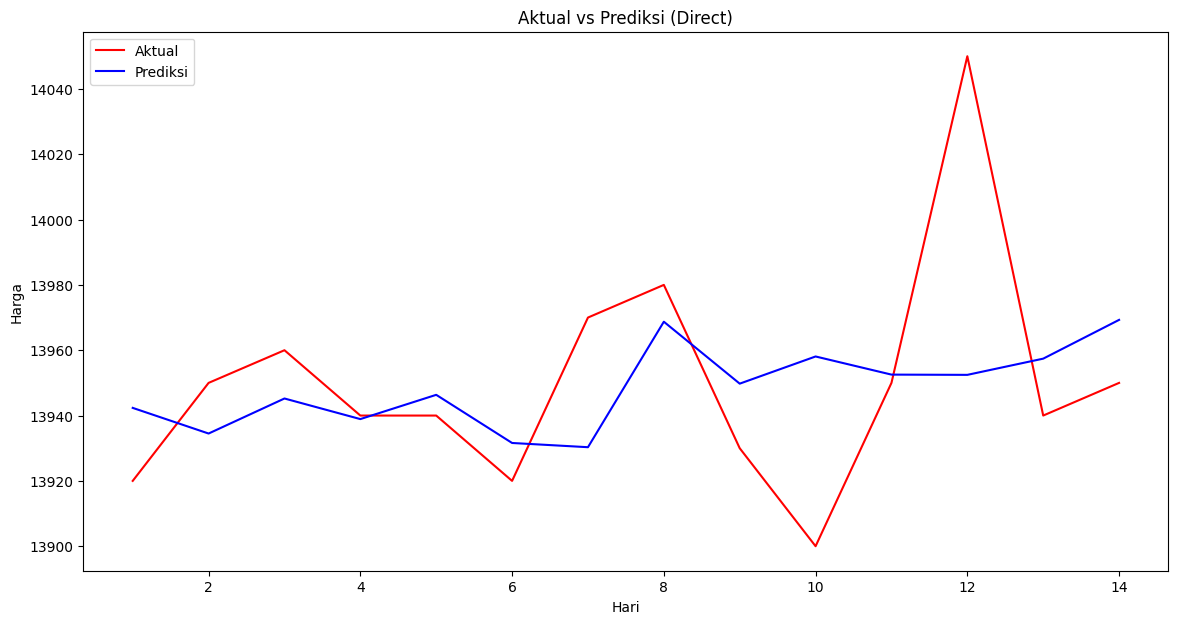

In [ ]:
plot_result_lstm('Direct', df_medium[-14:].values, direct_pred_val)

In [ ]:
for i, model in enumerate(models):
  model.save(f'lstm_model_tr_{i}.keras')

## Hybrid Model


In [ ]:
window_size = 5
steps = 14

In [ ]:
sc2 = MinMaxScaler(feature_range = (0,1))

def residualForLstm(actual, pred, scaller):
  temp = actual.copy()
  temp['pred'] = pred
  temp['residual'] = temp.iloc[:, 0] - temp.iloc[:, 1]
  residual = pd.DataFrame(temp['residual'][1:], columns=['residual'])
  resid_scaled = scaller.fit_transform(residual)

  return resid_scaled

In [ ]:
joblib.dump(sc2, 'model_final_forecasting/hybrid/scaler_hybrid.pkl')

### Get Best Parameters for Modelling Residual

In [ ]:
best_order = model_auto.order
best_seasonal = model_auto.seasonal_order

sarima_model = SARIMAX(train_md, order = best_order, seasonal_order = best_seasonal).fit()
sarima_pred1 = sarima_model.predict(start = train_md.index[0], end = train_md.index[-1])
sarima_pred1 = sarima_pred1.to_frame(name='pred')
sarima_pred1 = inv_boxcox(sarima_pred1, lmd)
resid_sc= residualForLstm(inv_boxcox(train_md, lmd), sarima_pred1, sc2)
x_resid, y_resid = make_data_direct(resid_sc, window_size, steps)

In [ ]:
import os
import shutil

In [ ]:
# tuner_dir = 'my_dir_hybrid'
# if os.path.exists(tuner_dir):
#     shutil.rmtree(tuner_dir)

In [ ]:
tuner2 = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials = 25,
    executions_per_trial=1,
    directory='/content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-md-hybrid',
    project_name='lstm_tuning'
)

Reloading Tuner from /content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-md-hybrid/lstm_tuning/tuner0.json


In [ ]:
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
#                                                   mode = 'min', patience = 200,
#                                                   restore_best_weights=True)

tuner2.search(x_resid, y_resid[:, 0],
              epochs=1000,
              validation_split = 0.2,
              batch_size=32,
              # callbacks=[early_stopping],
              verbose=0)

In [ ]:
best_param = tuner2.get_best_hyperparameters(num_trials=1)[0]
for param in best_param.values:
    print(f"{param}: {best_param.get(param)}")

units1: 64
dropout1: 0.30000000000000004
units2: 64
dropout2: 0.30000000000000004
learning_rate: 0.005


In [ ]:
# # import os
# source_dir = 'my_dir_hybrid'

# target_dir = '/content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-md-hybrid'

# shutil.copytree(source_dir, target_dir)

In [ ]:
def hybrid_model_fit(data, num_epoch, best_auto_am, scaller, val_split, tuner_name):
  best_lstm = tuner_name.get_best_models(num_models=1)[0]
  best_hps = tuner_name.get_best_hyperparameters(num_trials=1)[0]
  lr = best_hps.get('learning_rate')
  best_order = best_auto_am.order
  best_seasonal = best_auto_am.seasonal_order

  sarima_model= SARIMAX(data, order = best_order, seasonal_order = best_seasonal).fit()
  sarima_pred = sarima_model.predict(start = data.index[0], end = data.index[-1])
  sarima_pred = sarima_pred.to_frame(name='pred')
  resid_scaled = residualForLstm(inv_boxcox(data, lmd), inv_boxcox(sarima_pred, lmd), scaller)

  x, y = make_data_direct(resid_scaled, window_size, steps)

  lstm_model = []
  rows =  math.ceil(steps/2)
  cols = 2
  step_temp = 0

  fig,axs = plt.subplots(rows, cols, figsize=(15, 30))
  for i in range(rows):
    for j in range(cols):
      cloned_model = clone_model(best_lstm)
      cloned_model.compile(optimizer = keras.optimizers.Adam(learning_rate = lr),
                           loss = 'mse', metrics = ['mae', 'mape'])
      model, hist = fitting(cloned_model, x, y[:, (step_temp)], num_epoch, val_split, isHybrid = True)
      lstm_model.append(model)
      if step_temp < steps:
        ax = axs[i,j]
        ax.plot(hist.history['loss'], label=f'Model Loss ({step_temp+1})')
        ax.legend()
        step_temp += 1
      else:
        fig.delaxes(axs[i,j])
  plt.tight_layout()
  plt.show()

  return sarima_model, lstm_model

In [ ]:
from tensorflow.keras.models import load_model
lstm_model = []
# Memuat model dari file .h5
for i in range(14):
  model_tr = load_model(f'/content/drive/MyDrive/Tugas Akhir/final_model2/medium/model_final_forecasting/hybrid/lstm_model_tr_{i}_hybrid.keras')
  lstm_model.append(model_tr)
# Menampilkan ringkasan arsitektur model
# model.summary()

In [ ]:
arima_tr = train_md

In [ ]:
arima_tr = train_md
sarima_model, lstm_model= hybrid_model_fit(arima_tr, 1000, model_auto, sc2)

TypeError: hybrid_model_fit() missing 2 required positional arguments: 'val_split' and 'tuner_name'

In [ ]:
tuner3 = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials = 25,
    executions_per_trial=1,
    directory='/content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-md-hybrid-70',
    project_name='lstm_tuning'
)

Reloading Tuner from /content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-md-hybrid-70/lstm_tuning/tuner0.json


In [ ]:
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
#                                                   mode = 'min', patience = 200,
#                                                   restore_best_weights=True)

tuner3.search(x_resid, y_resid[:, 0],
              epochs=1000,
              validation_split = 0.3,
              batch_size=32,
              # callbacks=[early_stopping],
              verbose=0)

In [ ]:
best_param2 = tuner3.get_best_hyperparameters(num_trials=1)[0]
for param in best_param.values:
    print(f"{param}: {best_param.get(param)}")

units1: 64
dropout1: 0.30000000000000004
units2: 64
dropout2: 0.30000000000000004
learning_rate: 0.005


In [ ]:
# # import os
# source_dir = 'my_dir_hybrid2'

# target_dir = '/content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-md-hybrid-70'

# shutil.copytree(source_dir, target_dir)

In [ ]:
import joblib

In [ ]:
from tensorflow.keras.models import load_model
lstm_model2 = []
# Memuat model dari file .h5
for i in range(14):
  model_tr = load_model(f'/content/drive/MyDrive/Tugas Akhir/final_model2/medium/model_final_forecasting-60-70/hybrid-70/lstm_model_tr_{i}_hybrid.keras')
  lstm_model2.append(model_tr)

sarima_model2 = joblib.load('/content/drive/MyDrive/Tugas Akhir/final_model2/medium/model_final_forecasting-60-70/hybrid-70/sarima_model_tr_hybrid.pkl')

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


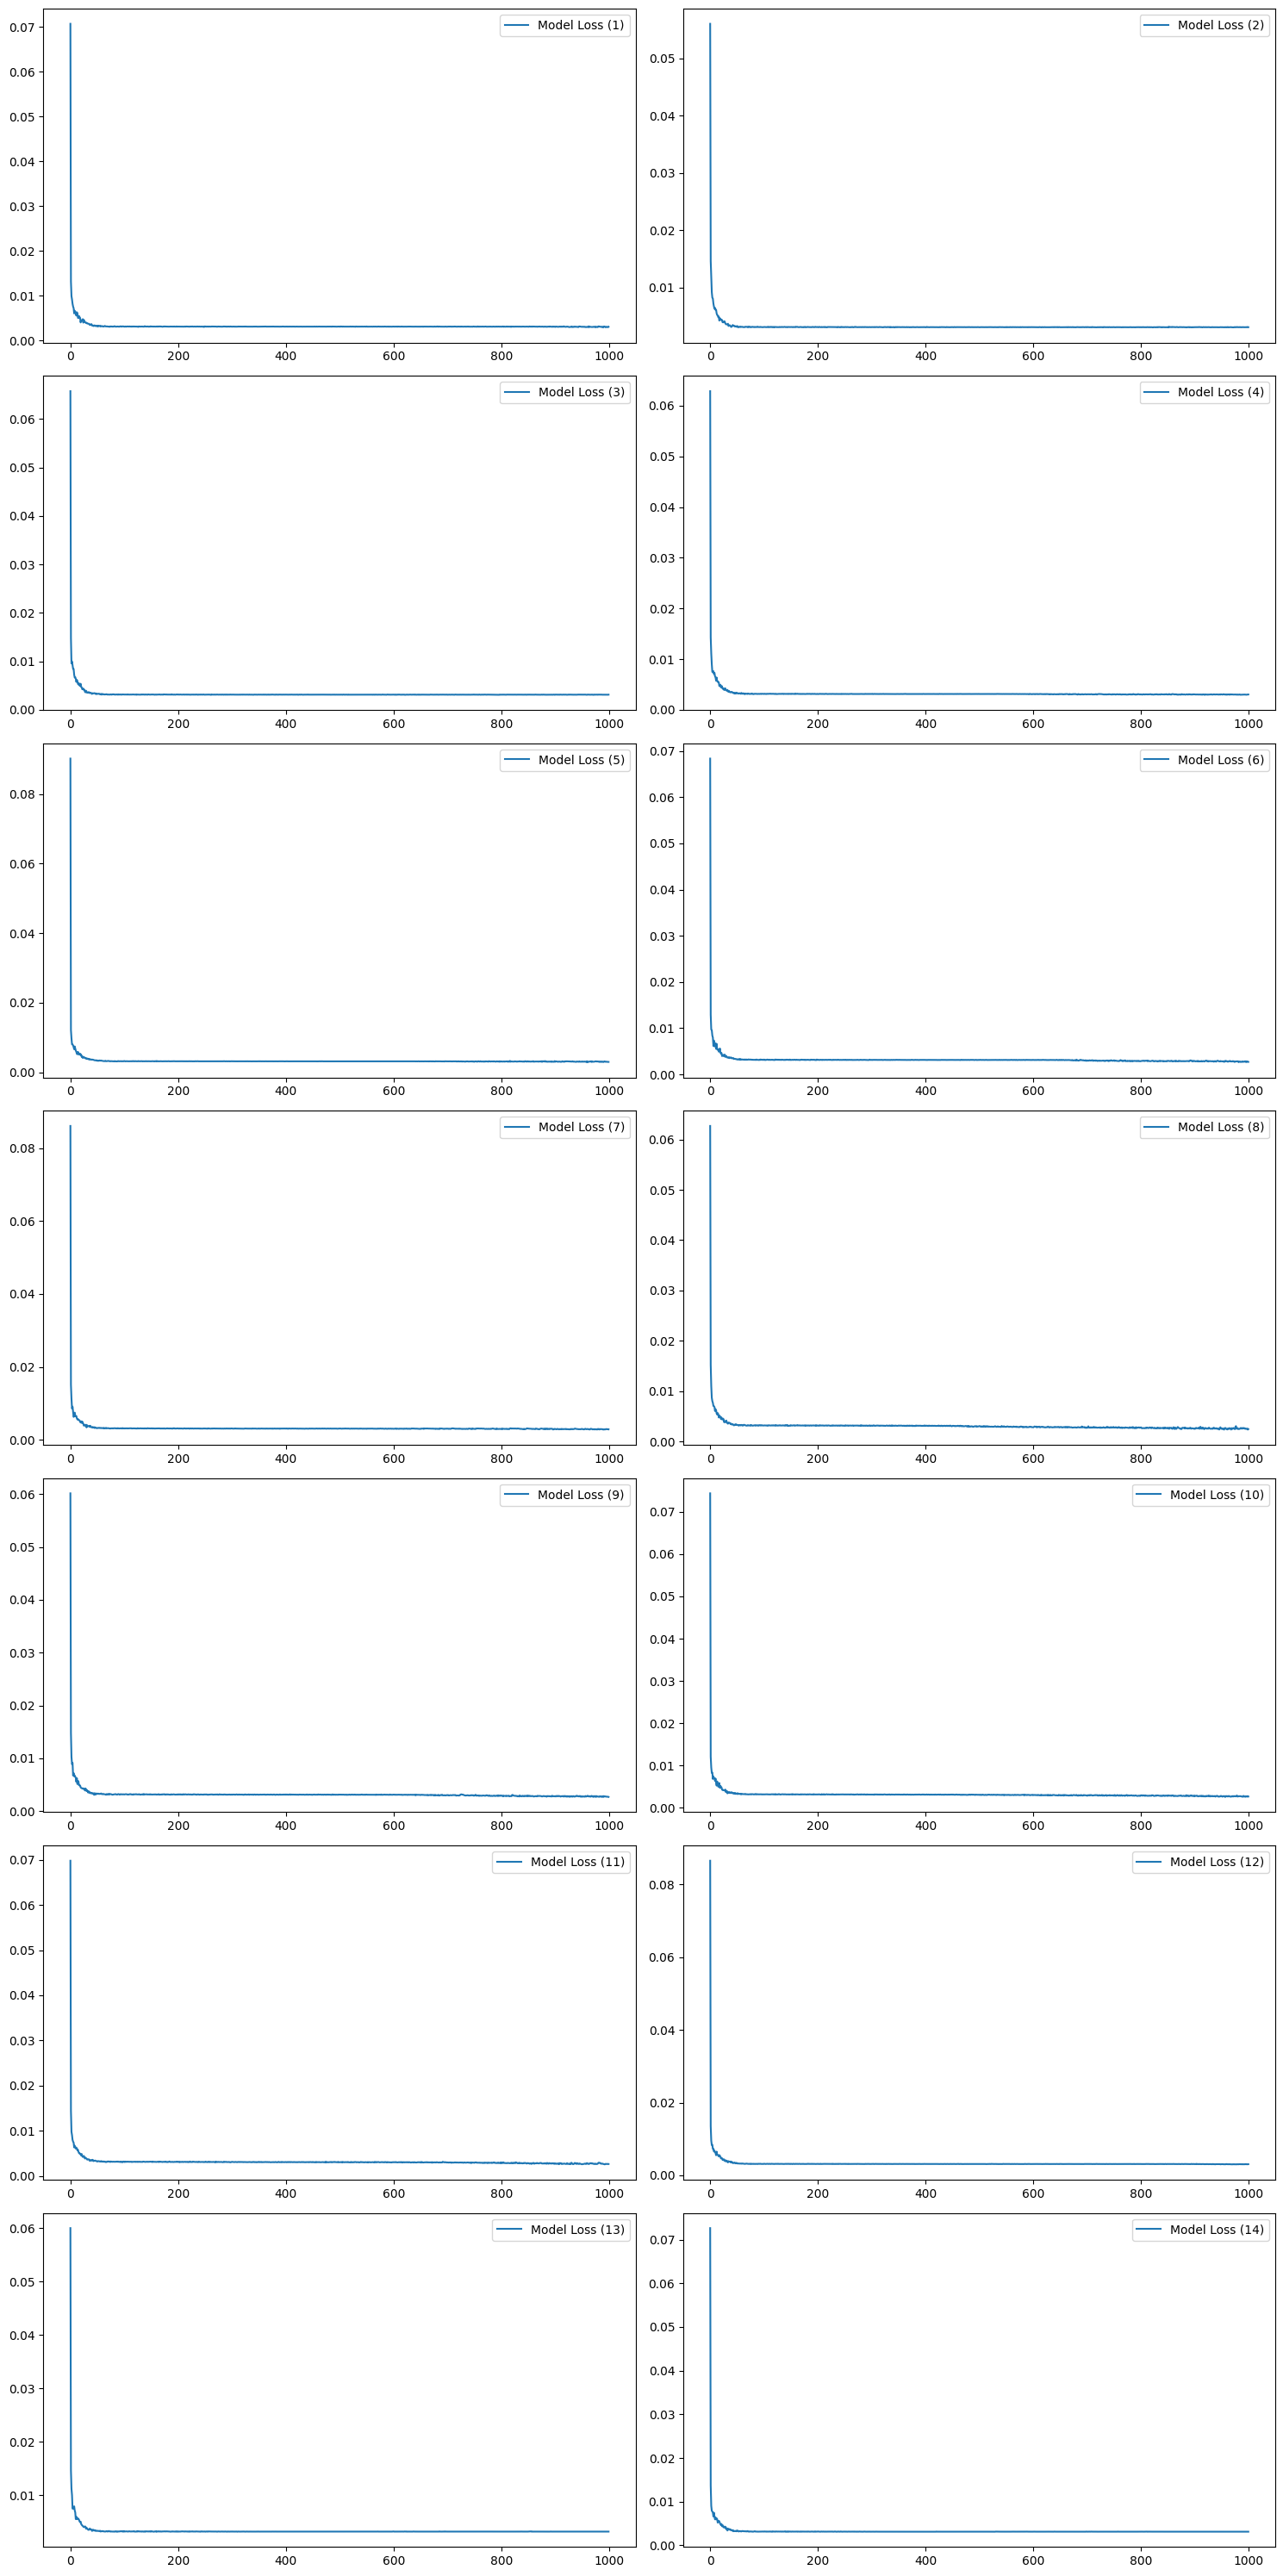

In [ ]:
sarima_model2, lstm_model2= hybrid_model_fit(arima_tr, 1000, model_auto, sc2, 0.3, tuner3)

In [ ]:
# os.makedirs('model_final_forecasting', exist_ok=True)
# os.makedirs('model_final_forecasting/arima', exist_ok=True)
# os.makedirs('model_final_forecasting/hybrid', exist_ok=True)
os.makedirs('model_final_forecasting/hybrid-70', exist_ok=True)
os.makedirs('model_final_forecasting/hybrid-60', exist_ok=True)

In [ ]:
#Export Model
joblib.dump(sarima_model2, 'model_final_forecasting/hybrid-70/sarima_model_tr_hybrid.pkl')

In [ ]:
for i, model in enumerate(lstm_model2):
  model.save(f'model_final_forecasting/hybrid-70/lstm_model_tr_{i}_hybrid.keras')

In [ ]:
tuner4 = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials = 25,
    executions_per_trial=1,
    directory='/content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-md-hybrid-60',
    project_name='lstm_tuning'
)

Reloading Tuner from /content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-md-hybrid-60/lstm_tuning/tuner0.json


In [ ]:
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
#                                                   mode = 'min', patience = 200,
#                                                   restore_best_weights=True)

tuner4.search(x_resid, y_resid[:, 0],
              epochs=1000,
              validation_split = 0.4,
              batch_size=32,
              # callbacks=[early_stopping],
              verbose=0)

In [ ]:
best_param3 = tuner4.get_best_hyperparameters(num_trials=1)[0]
for param in best_param.values:
    print(f"{param}: {best_param.get(param)}")

units1: 64
dropout1: 0.30000000000000004
units2: 64
dropout2: 0.30000000000000004
learning_rate: 0.005


In [ ]:
# # import os
# source_dir = 'my_dir_hybrid3'

# target_dir = '/content/drive/My Drive/Tugas Akhir/final_model2/hasil_tuner_lstm/lstm-md-hybrid-60'

# shutil.copytree(source_dir, target_dir)

In [ ]:
from tensorflow.keras.models import load_model
lstm_model3 = []
# Memuat model dari file .h5
for i in range(14):
  model_tr = load_model(f'/content/drive/MyDrive/Tugas Akhir/final_model2/medium/model_final_forecasting-60-70/hybrid-60/lstm_model_tr_{i}_hybrid.keras')
  lstm_model3.append(model_tr)

sarima_model3 = joblib.load('/content/drive/MyDrive/Tugas Akhir/final_model2/medium/model_final_forecasting-60-70/hybrid-60/sarima_model_tr_hybrid.pkl')

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


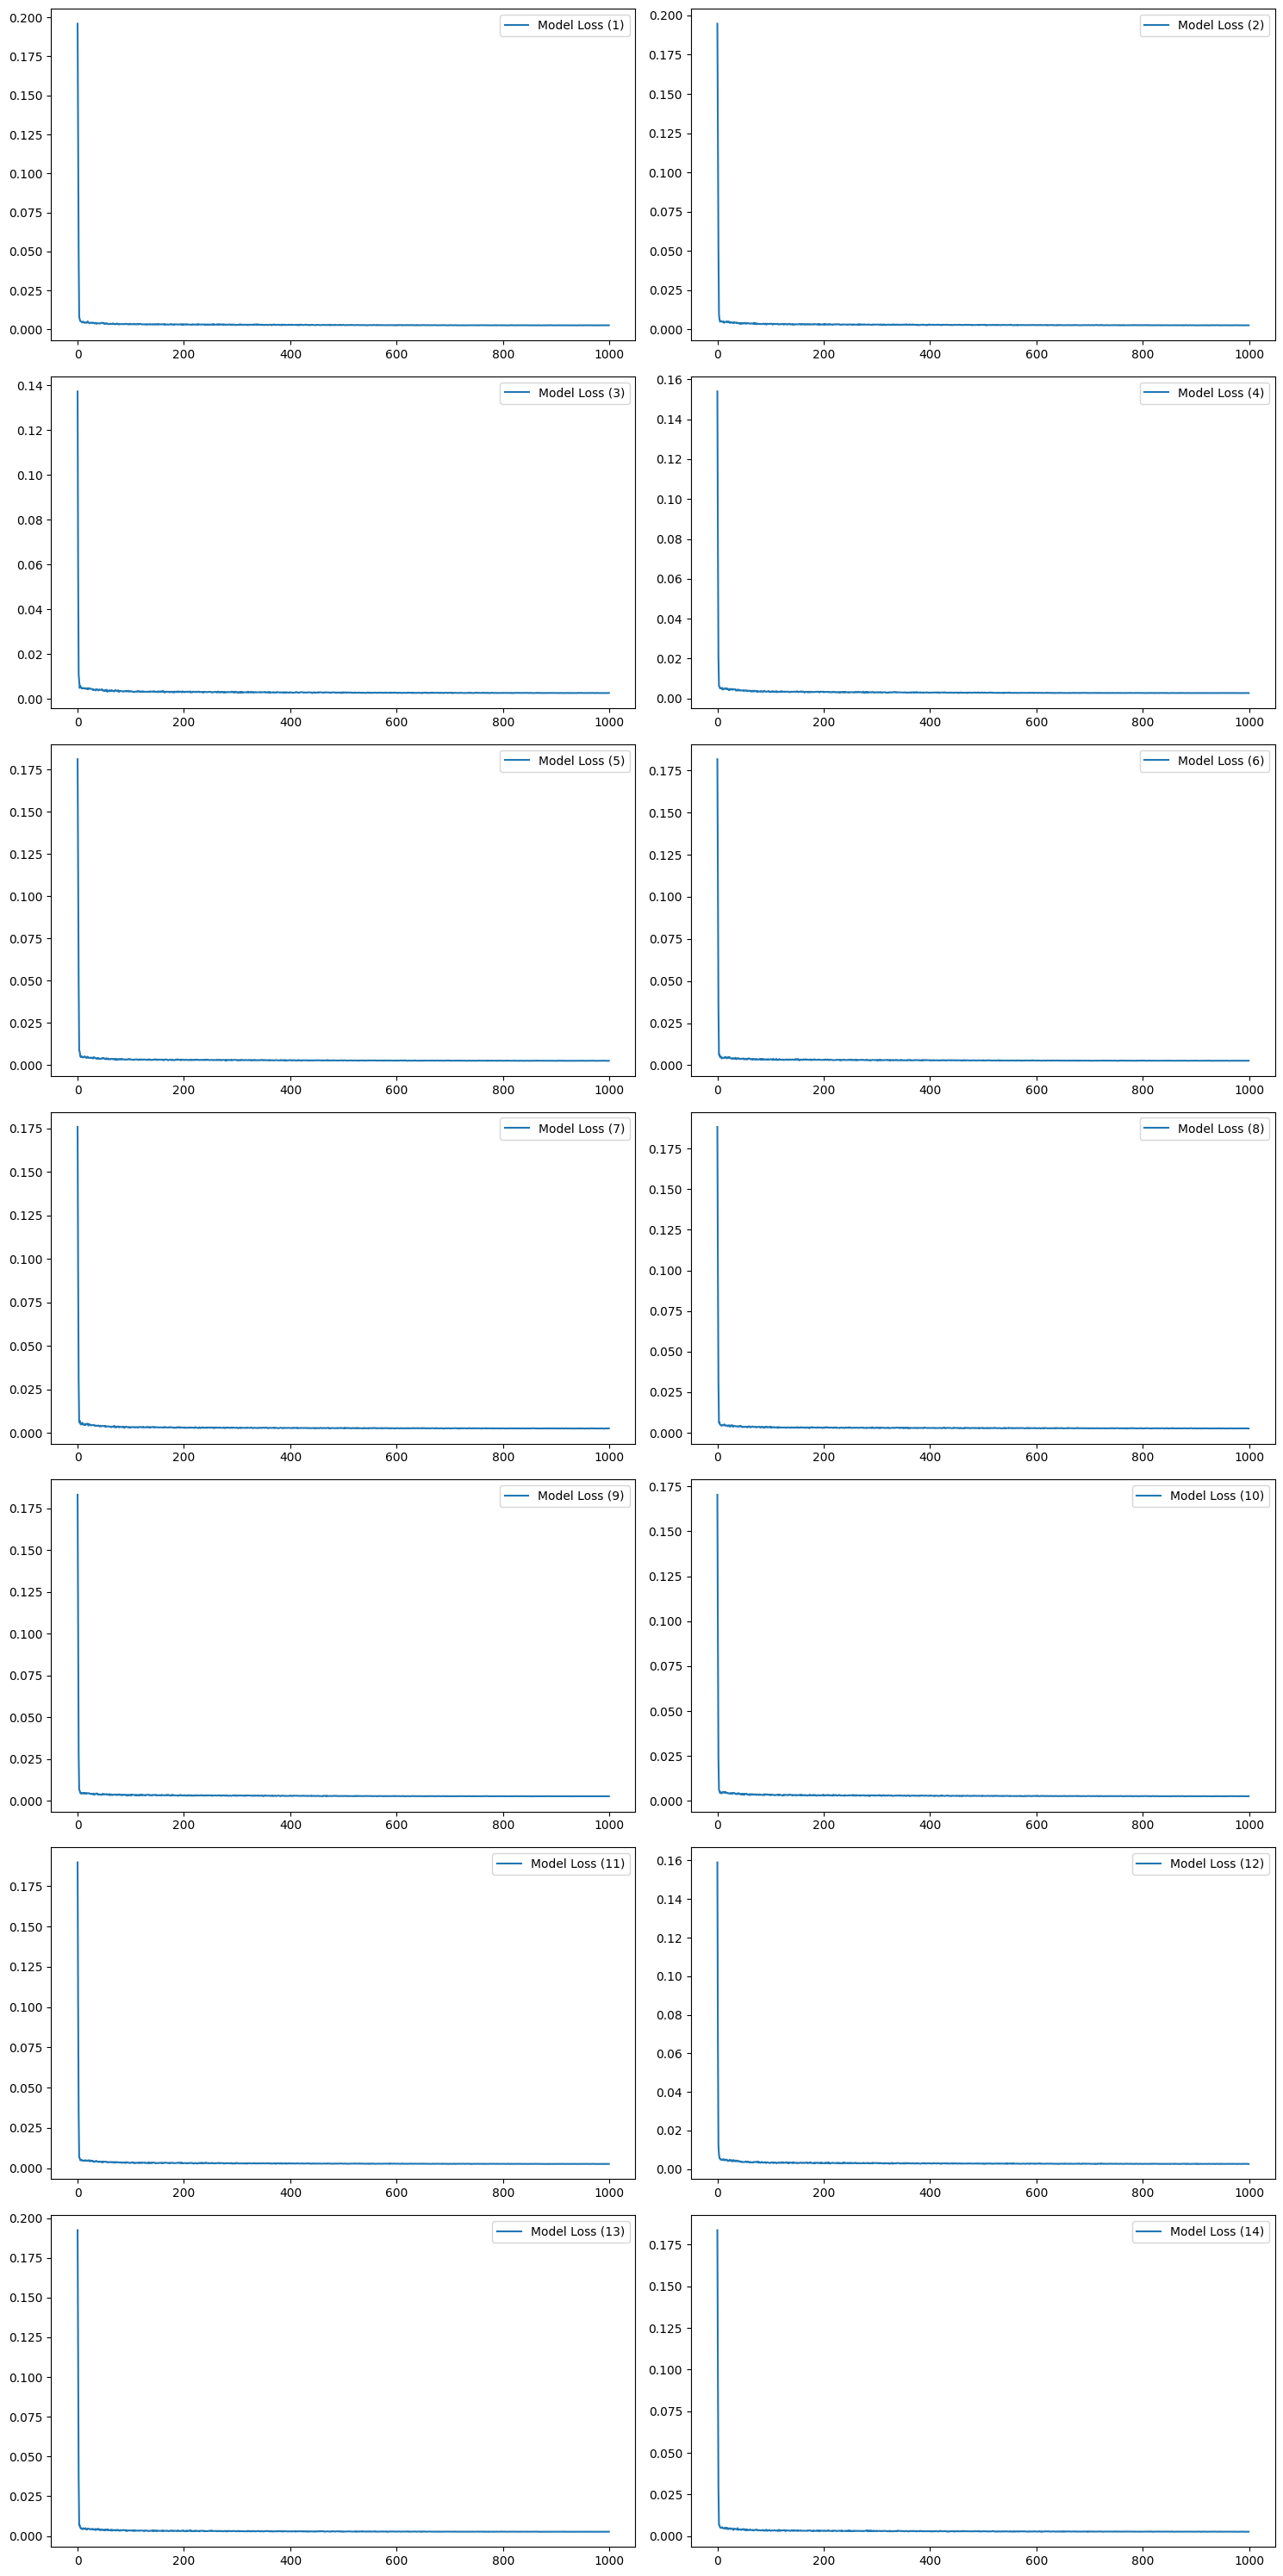

In [ ]:
sarima_model3, lstm_model3= hybrid_model_fit(arima_tr, 1000, model_auto, sc2, 0.4, tuner4)

In [ ]:
#Export Model
joblib.dump(sarima_model3, 'model_final_forecasting/hybrid-60/sarima_model_tr_hybrid.pkl')

In [ ]:
for i, model in enumerate(lstm_model3):
  model.save(f'model_final_forecasting/hybrid-60/lstm_model_tr_{i}_hybrid.keras')

In [ ]:
# # import os
# source_dir = 'model_final_forecasting'

# target_dir = '/content/drive/My Drive/Tugas Akhir/final_model2/medium/model_final_forecasting-60-70'

# shutil.copytree(source_dir, target_dir)

In [ ]:
def hybrid_model_predict(X, scaller, sm_model, lm_model):
  sarima_pred= sm_model.predict(start = X.index[0], end = X.index[-1])
  resid_scaled= residualForLstm(inv_boxcox(X, lmd), inv_boxcox(sarima_pred, lmd), scaller)
  x_am, y_am = make_data_direct(inv_boxcox(sarima_pred[1:], lmd), window_size, steps)
  x, y = make_data_direct(resid_scaled, window_size, steps)
  direct_pred = direct_lstm_pred(lm_model, x, scaller, steps)

  resid_pred = pd.DataFrame(direct_pred)
  sarima_pred2 = pd.DataFrame(y_am)
  final_pred = pd.DataFrame()
  for i in range(steps):
    final_pred[f'step {i+1}'] = sarima_pred2[i] + resid_pred[i]

  return final_pred
  # return sarima_pred2, x, resid_scaled,y, x_am, y_am

In [ ]:
hybrid_pred = hybrid_model_predict(arima_tr, sc2, sarima_model, lstm_model)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [ ]:
hybrid_pred_70 = hybrid_model_predict(arima_tr, sc2, sarima_model2, lstm_model2)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [ ]:
hybrid_pred_60 = hybrid_model_predict(arima_tr, sc2, sarima_model3, lstm_model3)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [ ]:
hybrid_pred.head()

,step 1,step 2,step 3,step 4,step 5,step 6,step 7,step 8,step 9,step 10,step 11,step 12,step 13,step 14
0,11037.564909,11039.110563,11050.321953,11065.592116,11073.917543,11094.583704,11085.787975,11123.670929,11092.921828,11048.614664,11080.572934,11073.062810,11083.556028,11079.511341
1,11044.977620,11052.452774,11066.563973,11075.123019,11103.723938,11094.210821,11096.460318,11113.860468,11063.400206,11090.942779,11105.441995,11110.420880,11092.365529,11090.805938
2,11049.068066,11062.655737,11079.699011,11093.326017,11090.735246,11096.063919,11122.232650,11104.550763,11089.012222,11106.176318,11101.575693,11088.774271,11106.807135,11131.574635
3,11064.926564,11077.199258,11095.739078,11090.552691,11092.692581,11125.363921,11102.101415,11077.377606,11107.649585,11093.002052,11089.072039,11107.300218,11127.752481,11105.656048
4,11078.881913,11094.636690,11092.870101,11091.265967,11122.974620,11105.050554,11074.640131,11115.888704,11107.870369,11082.397102,11106.396193,11130.697514,11097.050460,11098.739528


In [ ]:
train_len = math.floor(len(y_resid)*0.80)
train_len2 = math.floor(len(y_resid)*0.70)
train_len3 = math.floor(len(y_resid)*0.60)
x_actual, y_actual = make_data_direct(inv_boxcox(arima_tr[1:], lmd), window_size, steps)

In [ ]:
hybrid_error = lstm_error_direct(y_actual[:train_len], hybrid_pred[:train_len], sc2, steps, hybrid=True)
hybrid_error.head(14)

,Step,MAE,MAPE
0,1,32.031895,0.260265
1,2,32.015961,0.260226
2,3,32.001308,0.260003
3,4,30.961161,0.251817
4,5,31.526798,0.256264
5,6,30.232737,0.245899
6,7,30.740387,0.249689
7,8,25.777372,0.210558
8,9,25.767889,0.210134
9,10,21.130781,0.172494


In [ ]:
hybrid_error = lstm_error_direct(y_actual[train_len:], hybrid_pred[train_len:], sc2, steps, hybrid=True)
hybrid_error.head(14)

,Step,MAE,MAPE
0,1,45.825237,0.328995
1,2,49.420784,0.354681
2,3,46.029835,0.330468
3,4,47.126133,0.338164
4,5,46.302113,0.332164
5,6,48.832874,0.350281
6,7,50.106831,0.359426
7,8,59.302887,0.425117
8,9,52.640129,0.377402
9,10,51.957951,0.372620


In [ ]:
hybrid_error_70 = lstm_error_direct(y_actual[:train_len2], hybrid_pred_70[:train_len2], sc2, steps, hybrid=True)
hybrid_error_70.head(14)

,Step,MAE,MAPE
0,1,31.997972,0.263559
1,2,32.280972,0.265667
2,3,32.384903,0.266392
3,4,31.803715,0.261943
4,5,32.241344,0.265139
5,6,29.001827,0.239686
6,7,31.224882,0.256973
7,8,30.379330,0.250333
8,9,30.735287,0.253244
9,10,29.967123,0.246789


In [ ]:
hybrid_error_70 = lstm_error_direct(y_actual[train_len2:], hybrid_pred_70[train_len2:], sc2, steps, hybrid=True)
hybrid_error_70.head(14)

,Step,MAE,MAPE
0,1,40.899395,0.295671
1,2,41.268585,0.298331
2,3,41.213573,0.297885
3,4,41.643566,0.300901
4,5,41.735928,0.301526
5,6,45.265942,0.326829
6,7,47.272472,0.341055
7,8,43.920403,0.317101
8,9,46.605404,0.336169
9,10,42.812576,0.309174


In [ ]:
hybrid_error_60 = lstm_error_direct(y_actual[:train_len3], hybrid_pred_60[:train_len3], sc2, steps, hybrid=True)
hybrid_error_60.head(14)

,Step,MAE,MAPE
0,1,30.240738,0.253396
1,2,30.386536,0.254598
2,3,30.305983,0.253876
3,4,30.345051,0.254200
4,5,30.235765,0.253205
5,6,30.263945,0.253363
6,7,30.225225,0.253088
7,8,30.365110,0.254213
8,9,30.368799,0.254215
9,10,30.405041,0.254368


In [ ]:
hybrid_error_60 = lstm_error_direct(y_actual[train_len3:], hybrid_pred_60[train_len3:], sc2, steps, hybrid=True)
hybrid_error_60.head(14)

,Step,MAE,MAPE
0,1,41.398857,0.303353
1,2,41.119076,0.301192
2,3,41.155319,0.301433
3,4,41.413410,0.303277
4,5,41.401203,0.303128
5,6,41.376717,0.302872
6,7,42.223572,0.308761
7,8,41.261097,0.301732
8,9,41.011177,0.299763
9,10,41.165409,0.300843


In [ ]:
hybrid_pred2 = hybrid_model_predict(medium, sc2, sarima_model, lstm_model)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
# train_len2 = math.floor(len(y_resid)*0.80)
x_actual2, y_actual2 = make_data_direct(df_medium[1:], window_size, steps)

In [ ]:
hybrid_error2 = lstm_error_direct(y_actual2[-14:], hybrid_pred2[-14:], sc2, steps, hybrid=True)
hybrid_error2.head(14)

,Step,MAE,MAPE
0,1,23.776688,0.170979
1,2,23.986799,0.172414
2,3,23.632633,0.169938
3,4,22.688946,0.163003
4,5,19.265390,0.138395
5,6,18.757868,0.134733
6,7,19.326420,0.138760
7,8,25.055038,0.179811
8,9,21.805103,0.156433
9,10,31.272306,0.224432


In [ ]:
hybrid_pred2_70 = hybrid_model_predict(medium, sc2, sarima_model2, lstm_model2)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [ ]:
hybrid_error2_70 = lstm_error_direct(y_actual2[-14:], hybrid_pred2_70[-14:], sc2, steps, hybrid=True)
hybrid_error2_70.head(14)

,Step,MAE,MAPE
0,1,23.901337,0.171865
1,2,23.352268,0.167932
2,3,23.632904,0.169935
3,4,20.585066,0.147890
4,5,18.210703,0.130823
5,6,18.775185,0.134828
6,7,19.174192,0.137668
7,8,18.154213,0.130309
8,9,18.566483,0.133260
9,10,22.042736,0.158285


In [ ]:
hybrid_pred2_60 = hybrid_model_predict(medium, sc2, sarima_model3, lstm_model3)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
hybrid_error2_60 = lstm_error_direct(y_actual2[-14:], hybrid_pred2_60[-14:], sc2, steps, hybrid=True)
hybrid_error2_60.head(14)

,Step,MAE,MAPE
0,1,23.635849,0.169969
1,2,24.634924,0.177111
2,3,24.499275,0.176136
3,4,20.004211,0.143713
4,5,18.011749,0.129383
5,6,18.772692,0.134853
6,7,20.283463,0.145624
7,8,18.248144,0.130971
8,9,18.955366,0.136034
9,10,22.380566,0.160699


In [ ]:
hybrid_pred_val = hybrid_pred2[hybrid_pred2.shape[0]-1:]
hybrid_pred_val = hybrid_pred_val.transpose()

In [ ]:
hybrid_pred_val_70 = hybrid_pred2_70[hybrid_pred2_70.shape[0]-1:]
hybrid_pred_val_70 = hybrid_pred_val_70.transpose()

In [ ]:
hybrid_pred_val_60 = hybrid_pred2_60[hybrid_pred2_60.shape[0]-1:]
hybrid_pred_val_60 = hybrid_pred_val_60.transpose()

In [ ]:
pd.DataFrame(hybrid_pred_val)

,667
step 1,13953.114006
step 2,13952.756227
step 3,13955.473595
step 4,13946.351277
step 5,13955.981915
step 6,13952.077054
step 7,13955.338104
step 8,13965.987048
step 9,13946.477830
step 10,13954.102341


In [ ]:
hybrid_val_error = lstm_error(df_medium[-14:], hybrid_pred_val)
print(f'Test Errors : {hybrid_val_error}')

Test Errors : {'MAE': 21.68022, 'MAPE': 0.15523283}


In [ ]:
hybrid_val_error = lstm_error(df_medium[-14:], hybrid_pred_val_70)
print(f'Test Errors : {hybrid_val_error}')

Test Errors : {'MAE': 23.929235, 'MAPE': 0.17134902}


In [ ]:
hybrid_val_error = lstm_error(df_medium[-14:], hybrid_pred_val_60)
print(f'Test Errors : {hybrid_val_error}')

Test Errors : {'MAE': 23.607138, 'MAPE': 0.16903703}


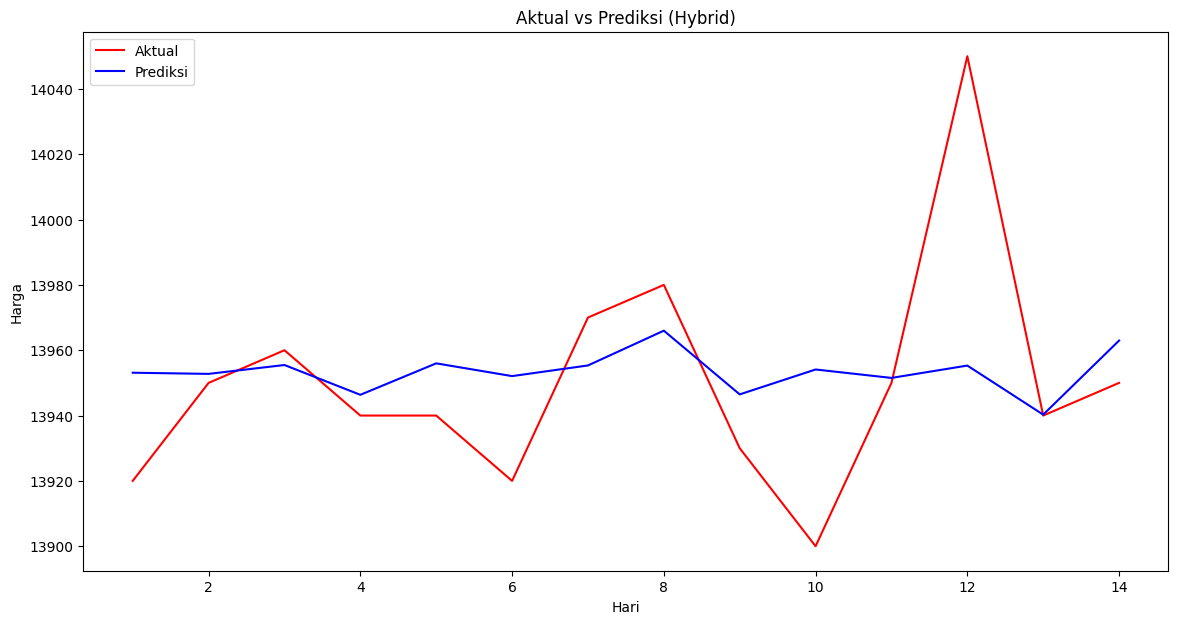

In [ ]:
plot_result_lstm('Hybrid', df_medium[-14:].values, hybrid_pred_val.values)

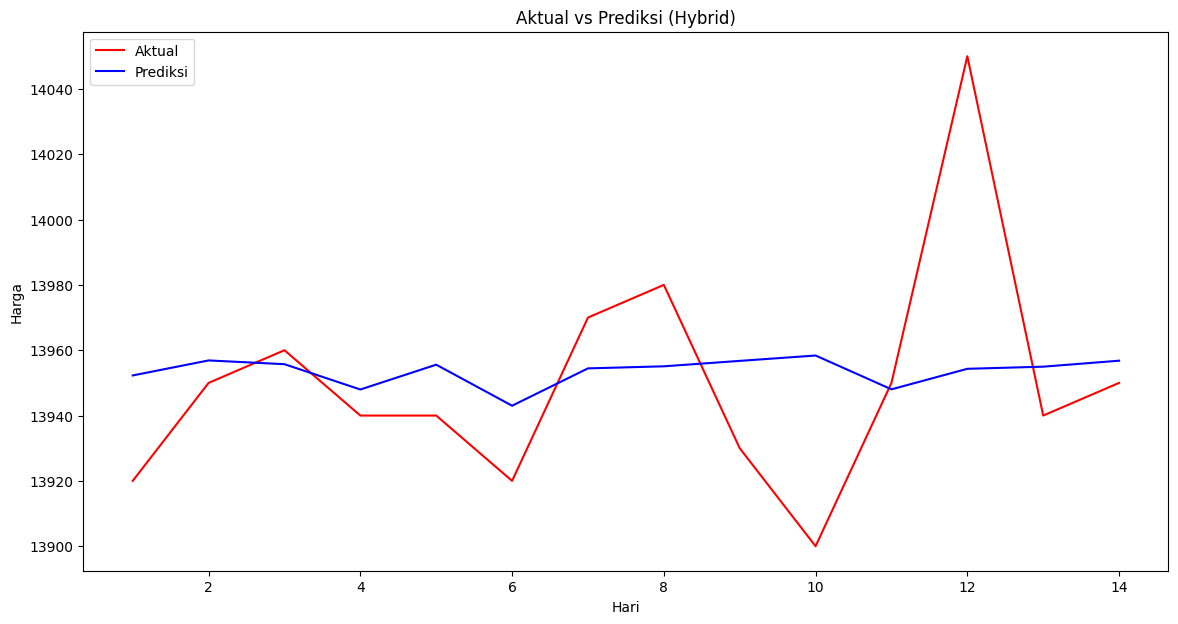

In [ ]:
plot_result_lstm('Hybrid', df_medium[-14:].values, hybrid_pred_val_70.values)

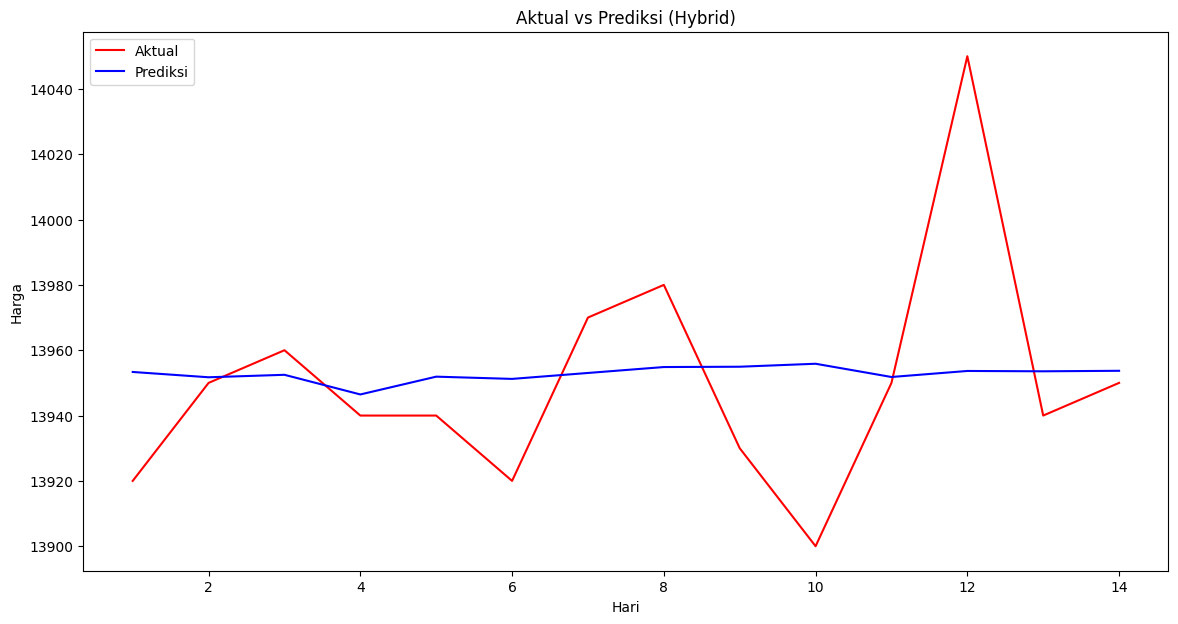

In [ ]:
plot_result_lstm('Hybrid', df_medium[-14:].values, hybrid_pred_val_60.values)

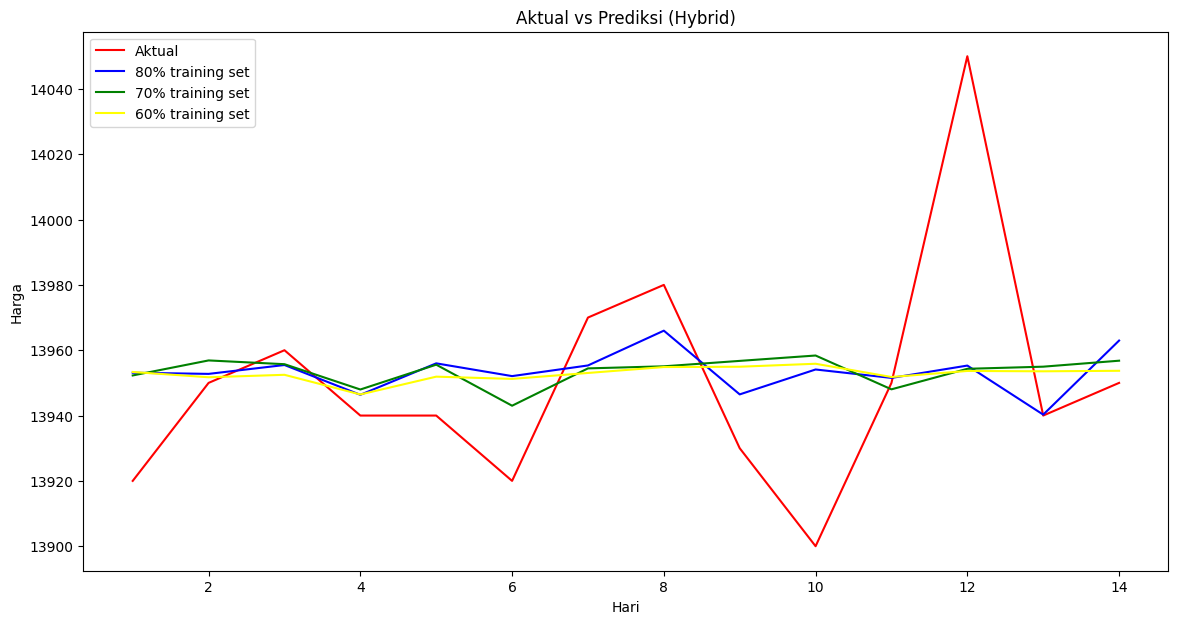

In [ ]:
plt.figure(figsize=(14, 7))
x_range = range(1, len(df_medium[-14:].values)+1)
plt.plot(x_range, df_medium[-14:].values, color ='red', label = 'Aktual')
plt.plot(x_range,  hybrid_pred_val.values, color = 'blue', label = '80% training set')
plt.plot(x_range,  hybrid_pred_val_70.values, color = 'green', label = '70% training set')
plt.plot(x_range,  hybrid_pred_val_60.values, color = 'yellow', label = '60% training set')
plt.title(f'Aktual vs Prediksi (Hybrid)')
plt.xlabel('Hari')
plt.ylabel('Harga')
plt.legend(['Aktual', '80% training set','70% training set','60% training set'], loc = 'upper left')
plt.show()

In [ ]:
# #Export Model
# import joblib

# joblib.dump(sarima_model, 'model_final_forecasting/hybrid/sarima_model_tr_hybrid.pkl')

In [ ]:
# for i, model in enumerate(lstm_model):
#   model.save(f'model_final_forecasting/hybrid/lstm_model_tr_{i}_hybrid.keras')

In [ ]:
model_auto2 = auto_arima(medium)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10

 ARIMA(0,1,0)(0,0,0)[7]             : AIC=-1058.280, Time=0.08 sec
 ARIMA(0,1,0)(0,0,1)[7]             : AIC=-1059.488, Time=0.84 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,2)[7]             : AIC=-1058.064, Time=3.22 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(2,1,1)(1,0,0)[7]             : AIC=-1159.556, Time=0.66 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(1,0,1)[7]             : AIC=-1160.070, Time=1.25 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(2,0,0)[7]             : AIC=-1159.378, Time=1.01 sec

Best model:  ARIMA(0,1,1)(1,0,1)[7]          
Total fit time: 127.268 seconds
                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  687
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 7)   Log Likelihood                 584.768
Date:                           Thu, 02 Jan 2025   AIC                          -1161.537
Time:                                   10:35:54   BIC                          -1143.413
Sample:                               07-15-2022   HQIC                         -1154.524
                                    - 05-31-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
keras.backend.clear_session()

In [ ]:
def hybrid_final_model_fit(data, num_epoch, best_auto_am, scaller,lmd):
  # best_lstm = tuner2.get_best_models(num_models=1)[0]
  best_hps = tuner2.get_best_hyperparameters(num_trials=1)[0]
  lr = best_hps.get('learning_rate')
  best_order = best_auto_am.order
  best_seasonal = best_auto_am.seasonal_order

  sarima_model2= SARIMAX(data, order = best_order, seasonal_order = best_seasonal).fit()
  sarima_pred = sarima_model2.predict(start = data.index[0], end = data.index[-1])
  sarima_pred = sarima_pred.to_frame(name='pred')
  resid_scaled = residualForLstm(inv_boxcox(data, lmd), inv_boxcox(sarima_pred, lmd), scaller)

  x_all, y_all = make_data_direct(resid_scaled, window_size, steps)
  # x = x[train_len2:]
  # y = y[train_len2:]

  lstm_model2 = []
  rows =  math.ceil(steps/2)
  cols = 2
  step_temp = 0
  fig,axs = plt.subplots(rows, cols, figsize=(15, 30))
  for i in range(rows):
    for j in range(cols):
      if step_temp >= steps:
        fig.delaxes(axs[i, j])  # Hapus sumbu jika tidak ada model lagi
        continue
      checkpoint = ModelCheckpoint(f'lstm_model_final_{step_temp}_hybrid.keras',
                                   monitor='loss',
                                   save_best_only=True,
                                   save_weights_only=False,
                                   mode='min',
                                   verbose=0)
      model = build_model(best_hps)
      hist = model.fit(x=x_all, y=y_all[:, (step_temp)],
                       epochs = num_epoch,
                       batch_size=32,
                       callbacks=[checkpoint],
                       verbose=0)
      lstm_model2.append(model)

      ax = axs[i,j]
      ax.plot(hist.history['loss'], label=f'Model Loss ({step_temp+1})')
      ax.legend()
      step_temp += 1

  plt.tight_layout()
  plt.show()

  return sarima_model2, lstm_model2

In [ ]:
data = medium
sc3 = MinMaxScaler(feature_range = (0,1))

In [ ]:
#Fitting final model for forecasting

sarima_model2, lstm_model2= hybrid_final_model_fit(data, 1000, model_auto2, sc3)

In [ ]:
lstm_model3 = []
# Memuat model dari file .h5
for i in range(14):
  model_tr = load_model(f'/content/drive/MyDrive/Tugas Akhir/final_model2_akhir6/medium/model_final_forecasting/lstm_model_final_{i}_hybrid.keras')
  lstm_model3.append(model_tr)
# Menampilkan ringkasan arsitektur model
# model.summary()

In [ ]:
sm_model = joblib.load('/content/drive/MyDrive/Tugas Akhir/final_model2_akhir6/medium/model_final_forecasting/sarima_model_final_hybrid.pkl')

In [ ]:
def make_data_input_only(data, window_size):
  x_inp = []
  for i in range(len(data) - window_size + 1):
    x_inp.append(data[i:(i + window_size)])

  return np.array(x_inp)

In [ ]:
def hybrid_model_predict_final(sm_model, lm_model, X, scaller, lmd):
  sm_pred= sm_model.predict(start = X.index[0], end = X.index[-1])
  sm_forecast= sm_model.forecast(steps=14)
  sm_forecast = inv_boxcox(sm_forecast, lmd)
  data_temp = inv_boxcox(X, lmd)
  data_temp['pred'] = inv_boxcox(sm_pred, lmd)
  data_temp['residual'] = data_temp.iloc[:, 0] - data_temp.iloc[:, 1]
  residual = pd.DataFrame(data_temp['residual'][1:], columns=['residual'])
  resid_sc = scaller.fit_transform(residual)
  x1 = make_data_input_only(resid_sc, window_size)
  direct_pred = direct_lstm_pred(lm_model, x1, scaller, steps)

  direct_pred1 = direct_pred[direct_pred.shape[0]-1:]
  direct_pred1 = direct_pred1.transpose()
  all_pred = sm_forecast.to_frame()
  all_pred['resid_pred'] = direct_pred1
  all_pred['result'] =  all_pred.iloc[:,0] + all_pred.iloc[:,1]

  # return all_pred['result'].to_frame(), residual, x1, direct_pred, data_temp['pred'],sm_forecast
  return all_pred['result'].to_frame()

In [ ]:
final_pred = hybrid_model_predict_final(sm_model, lstm_model3, data, sc3, lmd)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [ ]:
# sm_forecast

In [ ]:
final_pred

,result
2024-06-01,13966.074973
2024-06-02,13949.560878
2024-06-03,13960.569414
2024-06-04,13965.189607
2024-06-05,13962.596318
2024-06-06,13956.884346
2024-06-07,13962.047859
2024-06-08,13969.484096
2024-06-09,13891.317179
2024-06-10,13954.882016


In [ ]:
medium_new = df_medium_new.copy()
medium_new['beras_medium'], lmd_new = stats.boxcox(medium_new['beras_medium'])
data_new = medium_new
sc_new = MinMaxScaler(feature_range = (0,1))

In [ ]:
model_auto3 = auto_arima(data_new)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10

 ARIMA(0,1,0)(0,0,0)[7]             : AIC=74188.147, Time=0.15 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,1)[7]             : AIC=74189.940, Time=0.58 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(2,1,1)(1,0,0)[7]             : AIC=74013.914, Time=0.46 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(1,0,1)[7]             : AIC=74013.636, Time=1.67 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(2,0,0)[7]             : AIC=74014.731, Time=0.89 sec

Best model:  ARIMA(2,1,1)(0,0,0)[7]          
Total fit time: 168.334 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  901
Model:               SARIMAX(2, 1, 1)   Log Likelihood              -37002.558
Date:                Thu, 02 Jan 2025   AIC                          74013.117
Time:                        15:53:48   BIC                          74032.326
Sample:                    07-15-2022   HQIC                         74020.455
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1122      0.091     -1.234      0.217      -0.2

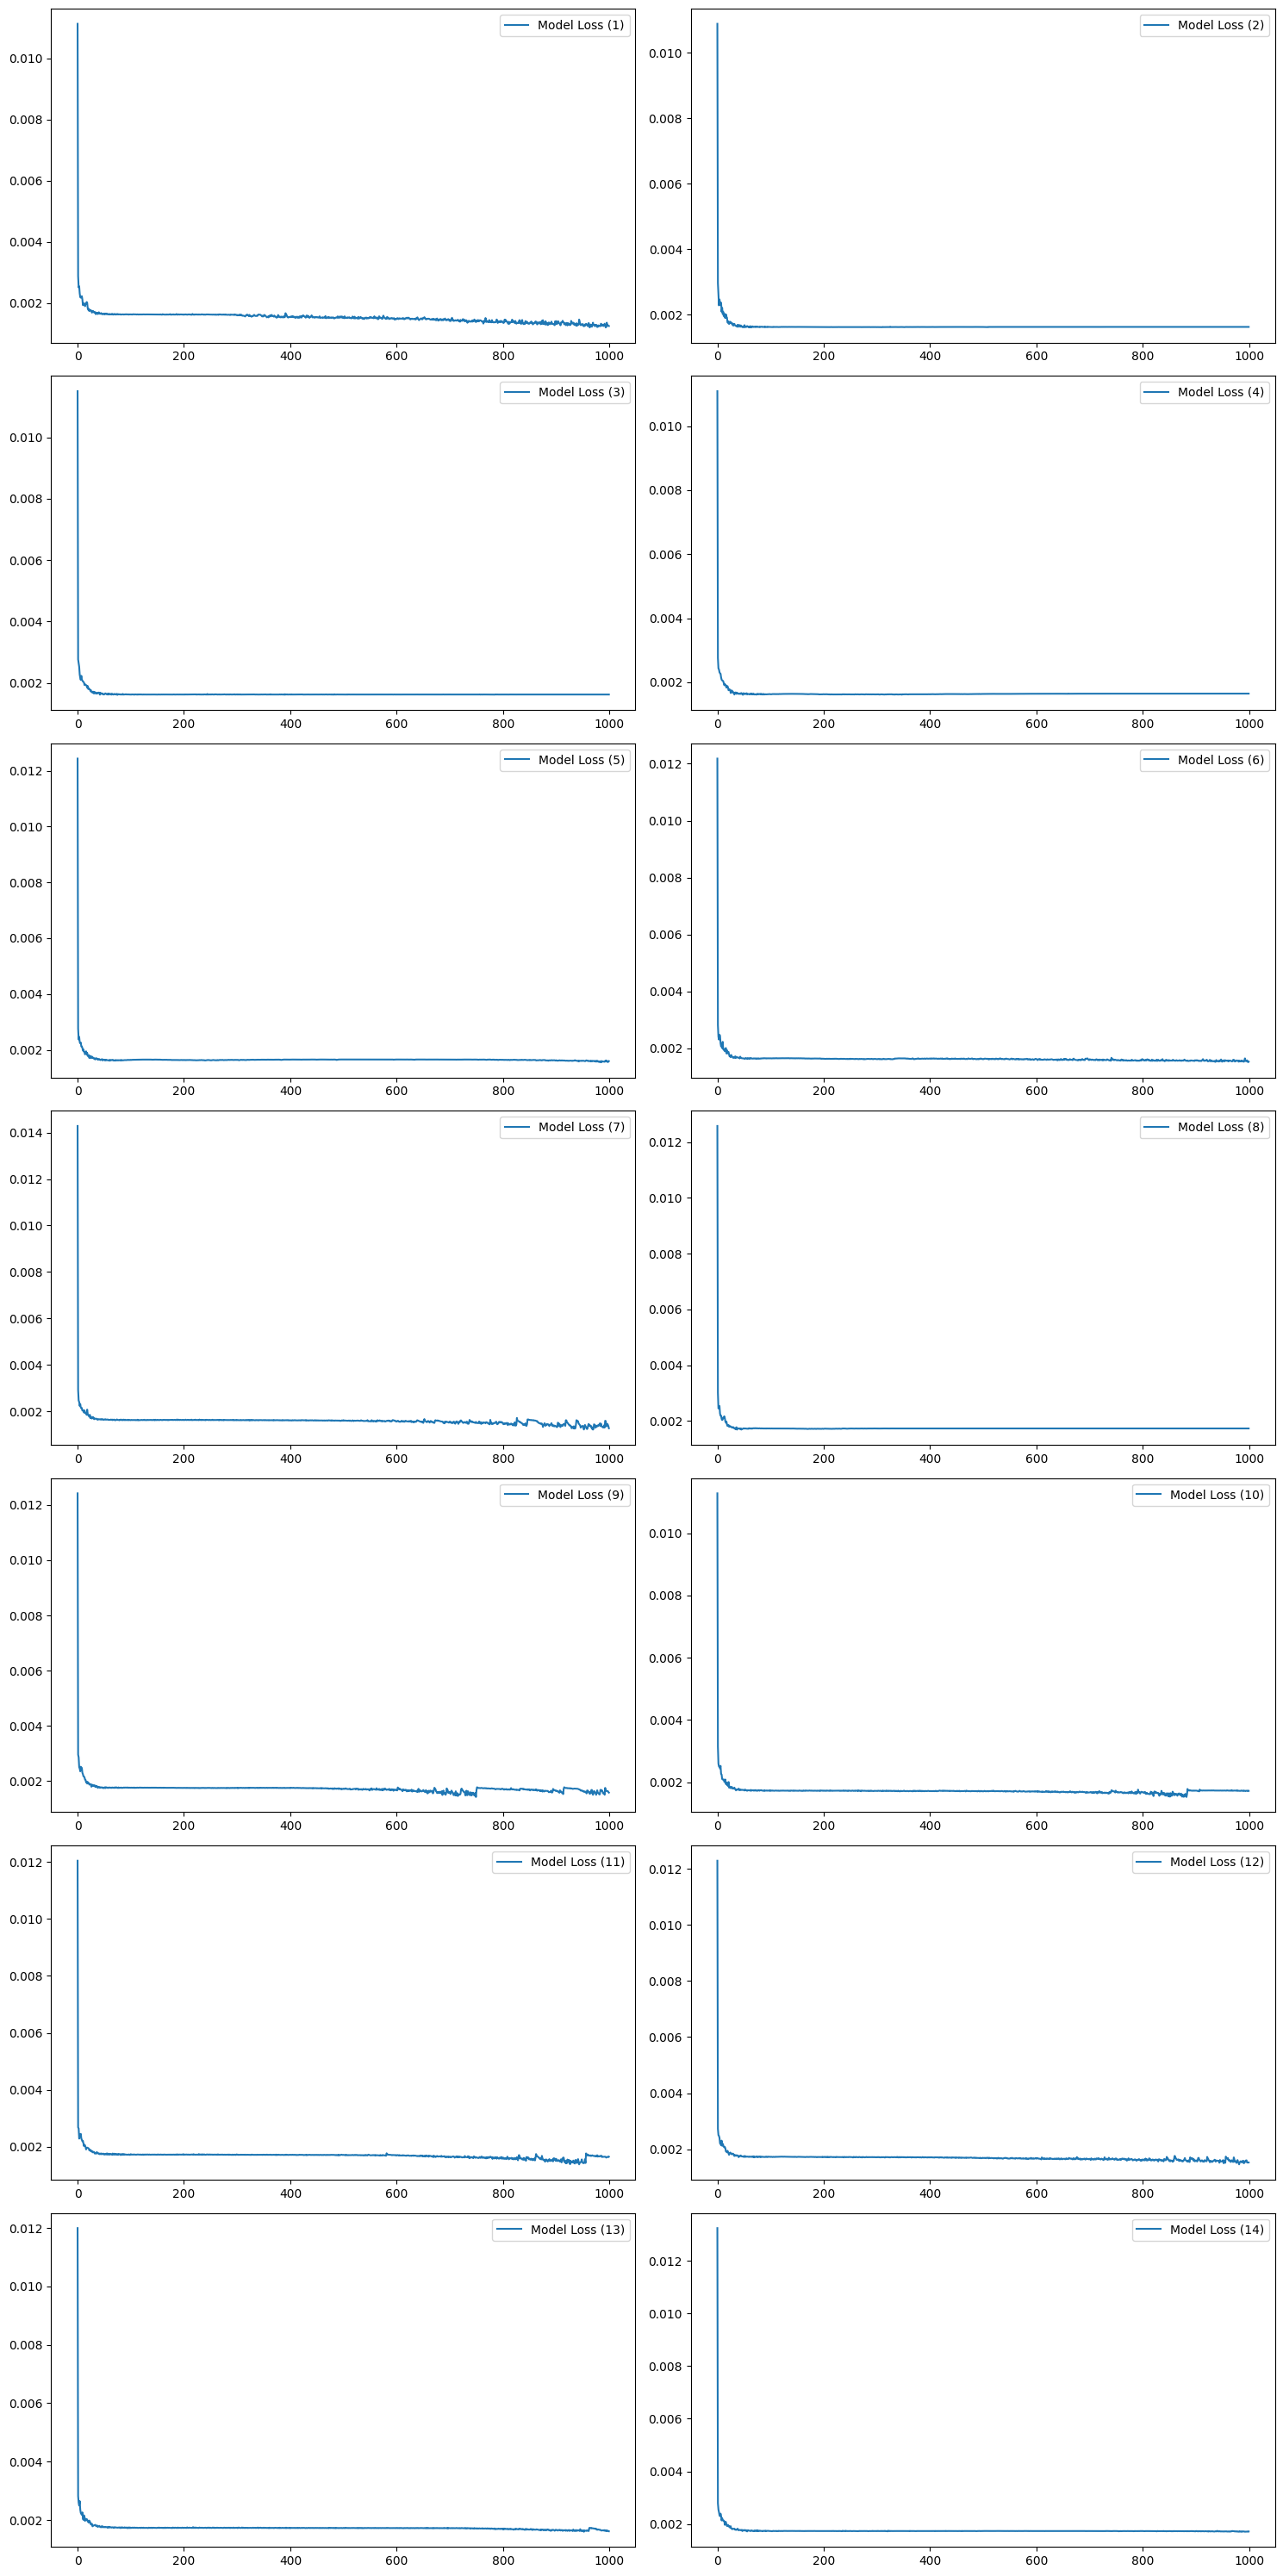

In [ ]:
sarima_model_new, lstm_model_new= hybrid_final_model_fit(data_new, 1000, model_auto3, sc_new, lmd_new)

In [ ]:
lstm_model4 = []
# Memuat model dari file .h5
for i in range(14):
  model_tr = load_model(f'lstm_model_final_{i}_hybrid.keras')
  lstm_model4.append(model_tr)
# Menampilkan ringkasan arsitektur model
# model.summary()

In [ ]:
import os
import joblib
os.makedirs('model_final_forecasting3', exist_ok=True)
joblib.dump(sc_new, 'model_final_forecasting3/scaller_final_hybrid.pkl')
#Export Model
joblib.dump(sarima_model_new, 'model_final_forecasting3/sarima_model_final_hybrid.pkl')
for i, model in enumerate(lstm_model4):
  model.save(f'model_final_forecasting3/lstm_model_final_{i}_hybrid.keras')
for i, model in enumerate(lstm_model_new):
  model.save(f'model_final_forecasting3/lstm_model_final_{i}_hybrid1.keras')
  #Export Model
joblib.dump(model_auto3, 'model_final_forecasting3/autoarima_final.pkl')

['model_final_forecasting3/autoarima_final.pkl']

In [ ]:
# import os
source_dir = 'model_final_forecasting3'

target_dir = '/content/drive/My Drive/Tugas Akhir/final_model2_akhir5/medium/model_final_forecasting3'

shutil.copytree(source_dir, target_dir)

'/content/drive/My Drive/Tugas Akhir/final_model2_akhir5/medium/model_final_forecasting3'

In [ ]:
import os

os.makedirs('model_final_forecasting2', exist_ok=True)

In [ ]:
joblib.dump(sc3, 'model_final_forecasting2/scaller_final_hybrid.pkl')

In [ ]:
#Export Model
joblib.dump(sarima_model, 'model_final_forecasting2/sarima_model_final_hybrid.pkl')

In [ ]:
for i, model in enumerate(lstm_model3):
  model.save(f'model_final_forecasting2/lstm_model_final_{i}_hybrid.keras')

In [ ]:
#Export Model
joblib.dump(model_auto, 'model_final_forecasting2/autoarima_tr.pkl')
joblib.dump(model_auto2, 'model_final_forecasting2/autoarima_final.pkl')

In [ ]:
# # import os
# source_dir = 'model_final_forecasting'

# target_dir = '/content/drive/My Drive/Tugas Akhir/final_model2/medium/model_final_forecasting'

# shutil.copytree(source_dir, target_dir)

In [ ]:
# import os
source_dir = 'model_final_forecasting2'

target_dir = '/content/drive/My Drive/Tugas Akhir/final_model2_akhir3/medium2/model_final_forecasting2'

shutil.copytree(source_dir, target_dir)